<center><span style="font-size:40px;"><b>NUTS vs HMC on GERMAN CREDIT CARD POSTERIOR (Hierarchical)</b></span></center>

In [51]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

import xarray as xr  # Imported to handle multi-dimensional tracking safely

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from tqdm.notebook import tqdm

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
#!pip3 install -U ucimlrepo 

---

---

---

# THE CONTEXT

Same as before, but but this time the variance parameter inthe prior on α and β is given an exponential prior and estimated as well.
Also, we expand the predictor vectors by including two-way interactions, resulting in $\binom{24}{2}$+24 = 300-dimensional
vectors of predictors x and a 300-dimensional vector of coefficients β. These elaborations on the model make for a more challenging problem; the posterior is in higher dimensions, and the variance term $\sigma^2$ interacts strongly with the remaining 301 variables.

N = 1000 is the number of customers and λ is the rate parameter to the prior on $\sigma^2$ . We set λ = 0.01, yielding a weak exponential prior distribution on $\sigma^2$ whose mean and standard deviation are 100.

The target distribution is $p(\alpha, \beta, \sigma^2 \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\beta| \sigma^2) p(\alpha|\sigma^2) p(\sigma^2) \, $, so:

$$
p(\alpha, \beta , \sigma^2 \mid X, y) \propto
\exp\left(
-\sum_{i}\log\!\left(1+\exp\!\left\{-y_i x_i \cdot \beta\right\}\right)
-\frac{\alpha^2}{2\sigma^2}
-\frac{1}{2\sigma^2}\,\beta \cdot \beta - \frac{N}{2}\log{\sigma^2} - \lambda \sigma^2
\right)
$$


# DATA UPLOAD (NUMERICAL VERSION)

This is the version with all numerical columns, and  also the one used in the No U Turn paper.

In [52]:
# URL to the numeric file o the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"

# Il file non ha header e usa spazi bianchi come separatore
df = pd.read_csv(url, sep='\s+', header=None)

# The last column is the target (1 = Good, 2 = Bad)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5418/3352265122.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None)


In [53]:
X

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,6,4,12,5,5,3,4,1,67,...,1,0,0,1,0,0,1,0,0,1
1,2,48,2,60,1,3,2,2,1,22,...,1,0,0,1,0,0,1,0,0,1
2,4,12,4,21,1,4,3,3,1,49,...,1,0,0,1,0,0,1,0,1,0
3,1,42,2,79,1,4,3,4,2,45,...,1,0,0,0,0,0,0,0,0,1
4,1,24,3,49,1,3,3,4,4,53,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,12,2,17,1,4,2,4,1,31,...,1,0,0,1,0,0,1,0,1,0
996,1,30,2,39,1,3,1,4,2,40,...,1,0,1,1,0,0,1,0,0,0
997,4,12,2,8,1,5,3,4,3,38,...,1,0,0,1,0,0,1,0,0,1
998,1,45,2,18,1,3,3,4,4,23,...,1,0,0,1,0,0,0,0,0,1


### NORMALIZATION and 2-WAY INTERACTIONS

In [54]:
# Introduce 2-way interactions: x_i * x_j for i different than j
# X is (N, 24)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_int = poly.fit_transform(X)

print(X.shape)      # (N, 24)
print(X_int.shape)  # (N, 300)

mu = X_int.mean(axis=0)
sd = X_int.std(axis=0, ddof=0)

# Z-score where the standard deviation is non-null
sd_safe = np.where(sd == 0, 1.0, sd)   # avoid division by 0
X_int = (X_int - mu) / sd_safe

# Target change from {1,2} to {-1, +1}
y = 2*y - 3
display(y)

(1000, 24)
(1000, 300)


0     -1
1      1
2     -1
3     -1
4      1
      ..
995   -1
996   -1
997   -1
998    1
999   -1
Name: 24, Length: 1000, dtype: int64

---

---

# MODEL TEST

In [66]:
# the variance parameter inthe prior on α and β is given an exponential prior and estimated as well
prior_mean = 0
prior_lambda = 0.01

TARGET_ACCEPT = 0.99
CHAINS = 4

In [67]:
with pm.Model() as model:
    X_data = pm.Data( "X", X_int )
    y_data = pm.Data( "y", y )

    # sigma2 = pm.Exponential("sigma2", lam=prior_lambda)
    # Priors: The exponential will give the term -lambda*sigma^2 ---> however, this doesn't sample well

    # We, instead, sample a real value and then impose the exponential 
    log_sigma2 = pm.Flat("log_sigma2")
    sigma2 = pm.Deterministic("sigma2", pm.math.exp(log_sigma2))
    sigma  = pm.Deterministic("sigma", pm.math.sqrt(sigma2))
    
    alpha = pm.Normal( "alpha", mu=prior_mean, sigma=sigma )
    beta  = pm.Normal( "beta",  mu=prior_mean, sigma=sigma, shape=X_data.shape[1] )

    # eta_i = x_i * beta
    eta = pm.math.dot( X_data, beta )

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # for numerical stability, we use logaddexp(x,y) = log(e^x + e^y); so the above softplus(z) = log(1 + exp(z)) = logaddexp(0, z)
    loglike = -pt.sum(pt.logaddexp(0.0, -y_data * eta))
    pm.Potential("likelihood", loglike)

    # missing factor depending on sigma and lambda
    pm.Potential("sigma2_prior", -(X_int.shape[0] / 2.0) * log_sigma2 - prior_lambda * sigma2)

    idata = pm.sample(
        draws=1000,
        tune=2000,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=2026,
        progressbar = True,
        nuts_sampler = "pymc"
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [log_sigma2, alpha, beta]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 85 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [68]:
print(idata)
print("posterior vars:", list(idata.posterior.data_vars))
print("posterior dims:", idata.posterior.dims)

for v in ["sigma2", "alpha", "beta"]:
    arr = idata.posterior[v].values
    print(v, arr.shape, np.nanmin(arr), np.nanmax(arr))

Inference data with groups:
	> posterior
	> sample_stats
	> constant_data
posterior vars: ['log_sigma2', 'alpha', 'beta', 'sigma2', 'sigma']
posterior dims: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 1000, 'beta_dim_0': 300})
sigma2 (4, 1000) 4.5523746392663465e-19 1.1496647100127755e-18
alpha (4, 1000) -2.7562089334489303e-09 3.0832140509934685e-09
beta (4, 1000, 300) -4.853139347352036e-09 4.783079890200106e-09


In [69]:
summary_nuts = az.summary(idata, var_names=["alpha", "beta", "sigma2", "sigma"])
display(summary_nuts)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.0,0.0,-0.0,0.0,0.0,0.0,6529.0,2868.0,1.02
beta[0],0.0,0.0,-0.0,0.0,0.0,0.0,6938.0,2560.0,1.02
beta[1],0.0,0.0,-0.0,0.0,0.0,0.0,6564.0,852.0,1.03
beta[2],0.0,0.0,-0.0,0.0,0.0,0.0,6145.0,1432.0,1.02
beta[3],0.0,0.0,-0.0,0.0,0.0,0.0,6167.0,1969.0,1.02
...,...,...,...,...,...,...,...,...,...
beta[297],0.0,0.0,-0.0,0.0,0.0,0.0,5860.0,1639.0,1.02
beta[298],0.0,0.0,-0.0,0.0,0.0,0.0,6450.0,478.0,1.02
beta[299],0.0,0.0,-0.0,0.0,0.0,0.0,5983.0,2427.0,1.03
sigma2,0.0,0.0,0.0,0.0,0.0,0.0,5.0,17.0,3.19


In [70]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
print("mean step_size:", float(idata.sample_stats["step_size"].mean()))
print("min step_size:", float(idata.sample_stats["step_size"].min()))

for v in ["sigma2", "alpha"]:
    vals = idata.posterior[v].values
    print(v, "min/max:", np.min(vals), np.max(vals), "unique-ish:", np.unique(vals.reshape(-1)[:20]))

divergences: 0
mean step_size: 9.377832724801632e-05
min step_size: 7.550107193641985e-05
sigma2 min/max: 4.5523746392663465e-19 1.1496647100127755e-18 unique-ish: [1.14966464e-18 1.14966464e-18 1.14966464e-18 1.14966464e-18
 1.14966464e-18 1.14966464e-18 1.14966464e-18 1.14966464e-18
 1.14966464e-18 1.14966464e-18 1.14966464e-18 1.14966465e-18
 1.14966465e-18 1.14966465e-18 1.14966465e-18 1.14966465e-18
 1.14966465e-18 1.14966465e-18 1.14966465e-18 1.14966465e-18]
alpha min/max: -2.7562089334489303e-09 3.0832140509934685e-09 unique-ish: [-1.34670088e-09 -1.21939361e-09 -1.05918066e-09 -7.35142119e-10
 -7.26571501e-10 -7.18596015e-10 -7.05832824e-10 -3.07445303e-10
 -1.47118497e-10 -1.22683746e-10 -1.05161810e-10  2.04800725e-10
  2.93769743e-10  3.11030994e-10  3.93499257e-10  5.66939848e-10
  5.70179022e-10  8.20592941e-10  9.50698836e-10  1.71630877e-09]


Number of parameters with R_hat > 1.05: 2


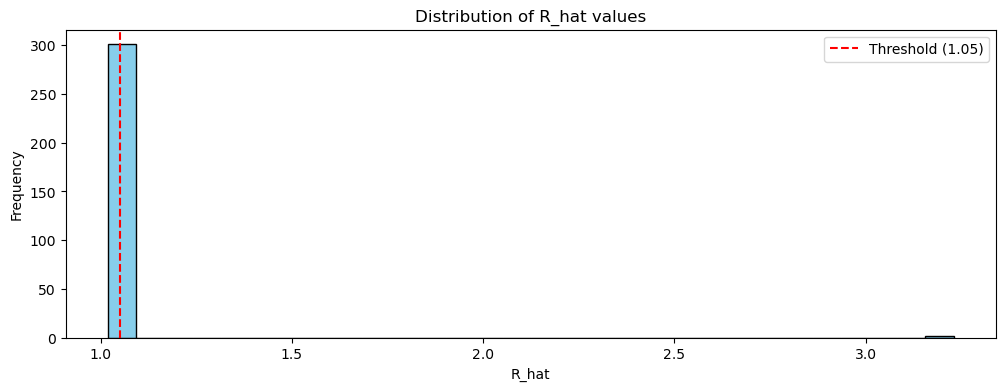

Number of parameters with ESS_bulk < 400: 2

Parameters with R_hat > 1.05:
        mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sigma2   0.0  0.0     0.0      0.0        0.0      0.0       4.0      15.0   
sigma    0.0  0.0     0.0      0.0        0.0      0.0       4.0      15.0   

        r_hat  
sigma2   3.23  
sigma    3.23  
Number of divergences: 0


In [64]:
# 1) Count how many rows exceed R_hat > 1.05
rhat_exceed = (summary_nuts['r_hat'] > 1.05).sum()
print(f"Number of parameters with R_hat > 1.05: {rhat_exceed}")

# 2) Plot the distribution of R_hat
plt.figure(figsize=(12, 4))
plt.hist(summary_nuts['r_hat'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(1.05, color='red', linestyle='--', label='Threshold (1.05)')
plt.title('Distribution of R_hat values')
plt.xlabel('R_hat')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3) Check ESS (Effective Sample Size)
# Generally, we look at 'ess_bulk' or 'ess_tail'
# A common rule of thumb is ESS > 100 * number of chains (e.g., 400)
ess_threshold = 400
low_ess = (summary_nuts['ess_bulk'] < ess_threshold).sum()
print(f"Number of parameters with ESS_bulk < {ess_threshold}: {low_ess}")

# Optional: Display parameters that failed the checks
if rhat_exceed > 0:
    print("\nParameters with R_hat > 1.05:")
    print(summary_nuts[summary_nuts['r_hat'] > 1.05])

print("Number of divergences:", int(idata.sample_stats["diverging"].sum()))

/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta\n0', ylabel='beta\n7'>,
        <Axes: xlabel='beta\n1'>, <Axes: xlabel='beta\n2'>,
        <Axes: xlabel='beta\n3'>, <Axes: xlabel='beta\n4'>,
        <Axes: xlabel='beta\n5'>, <Ax

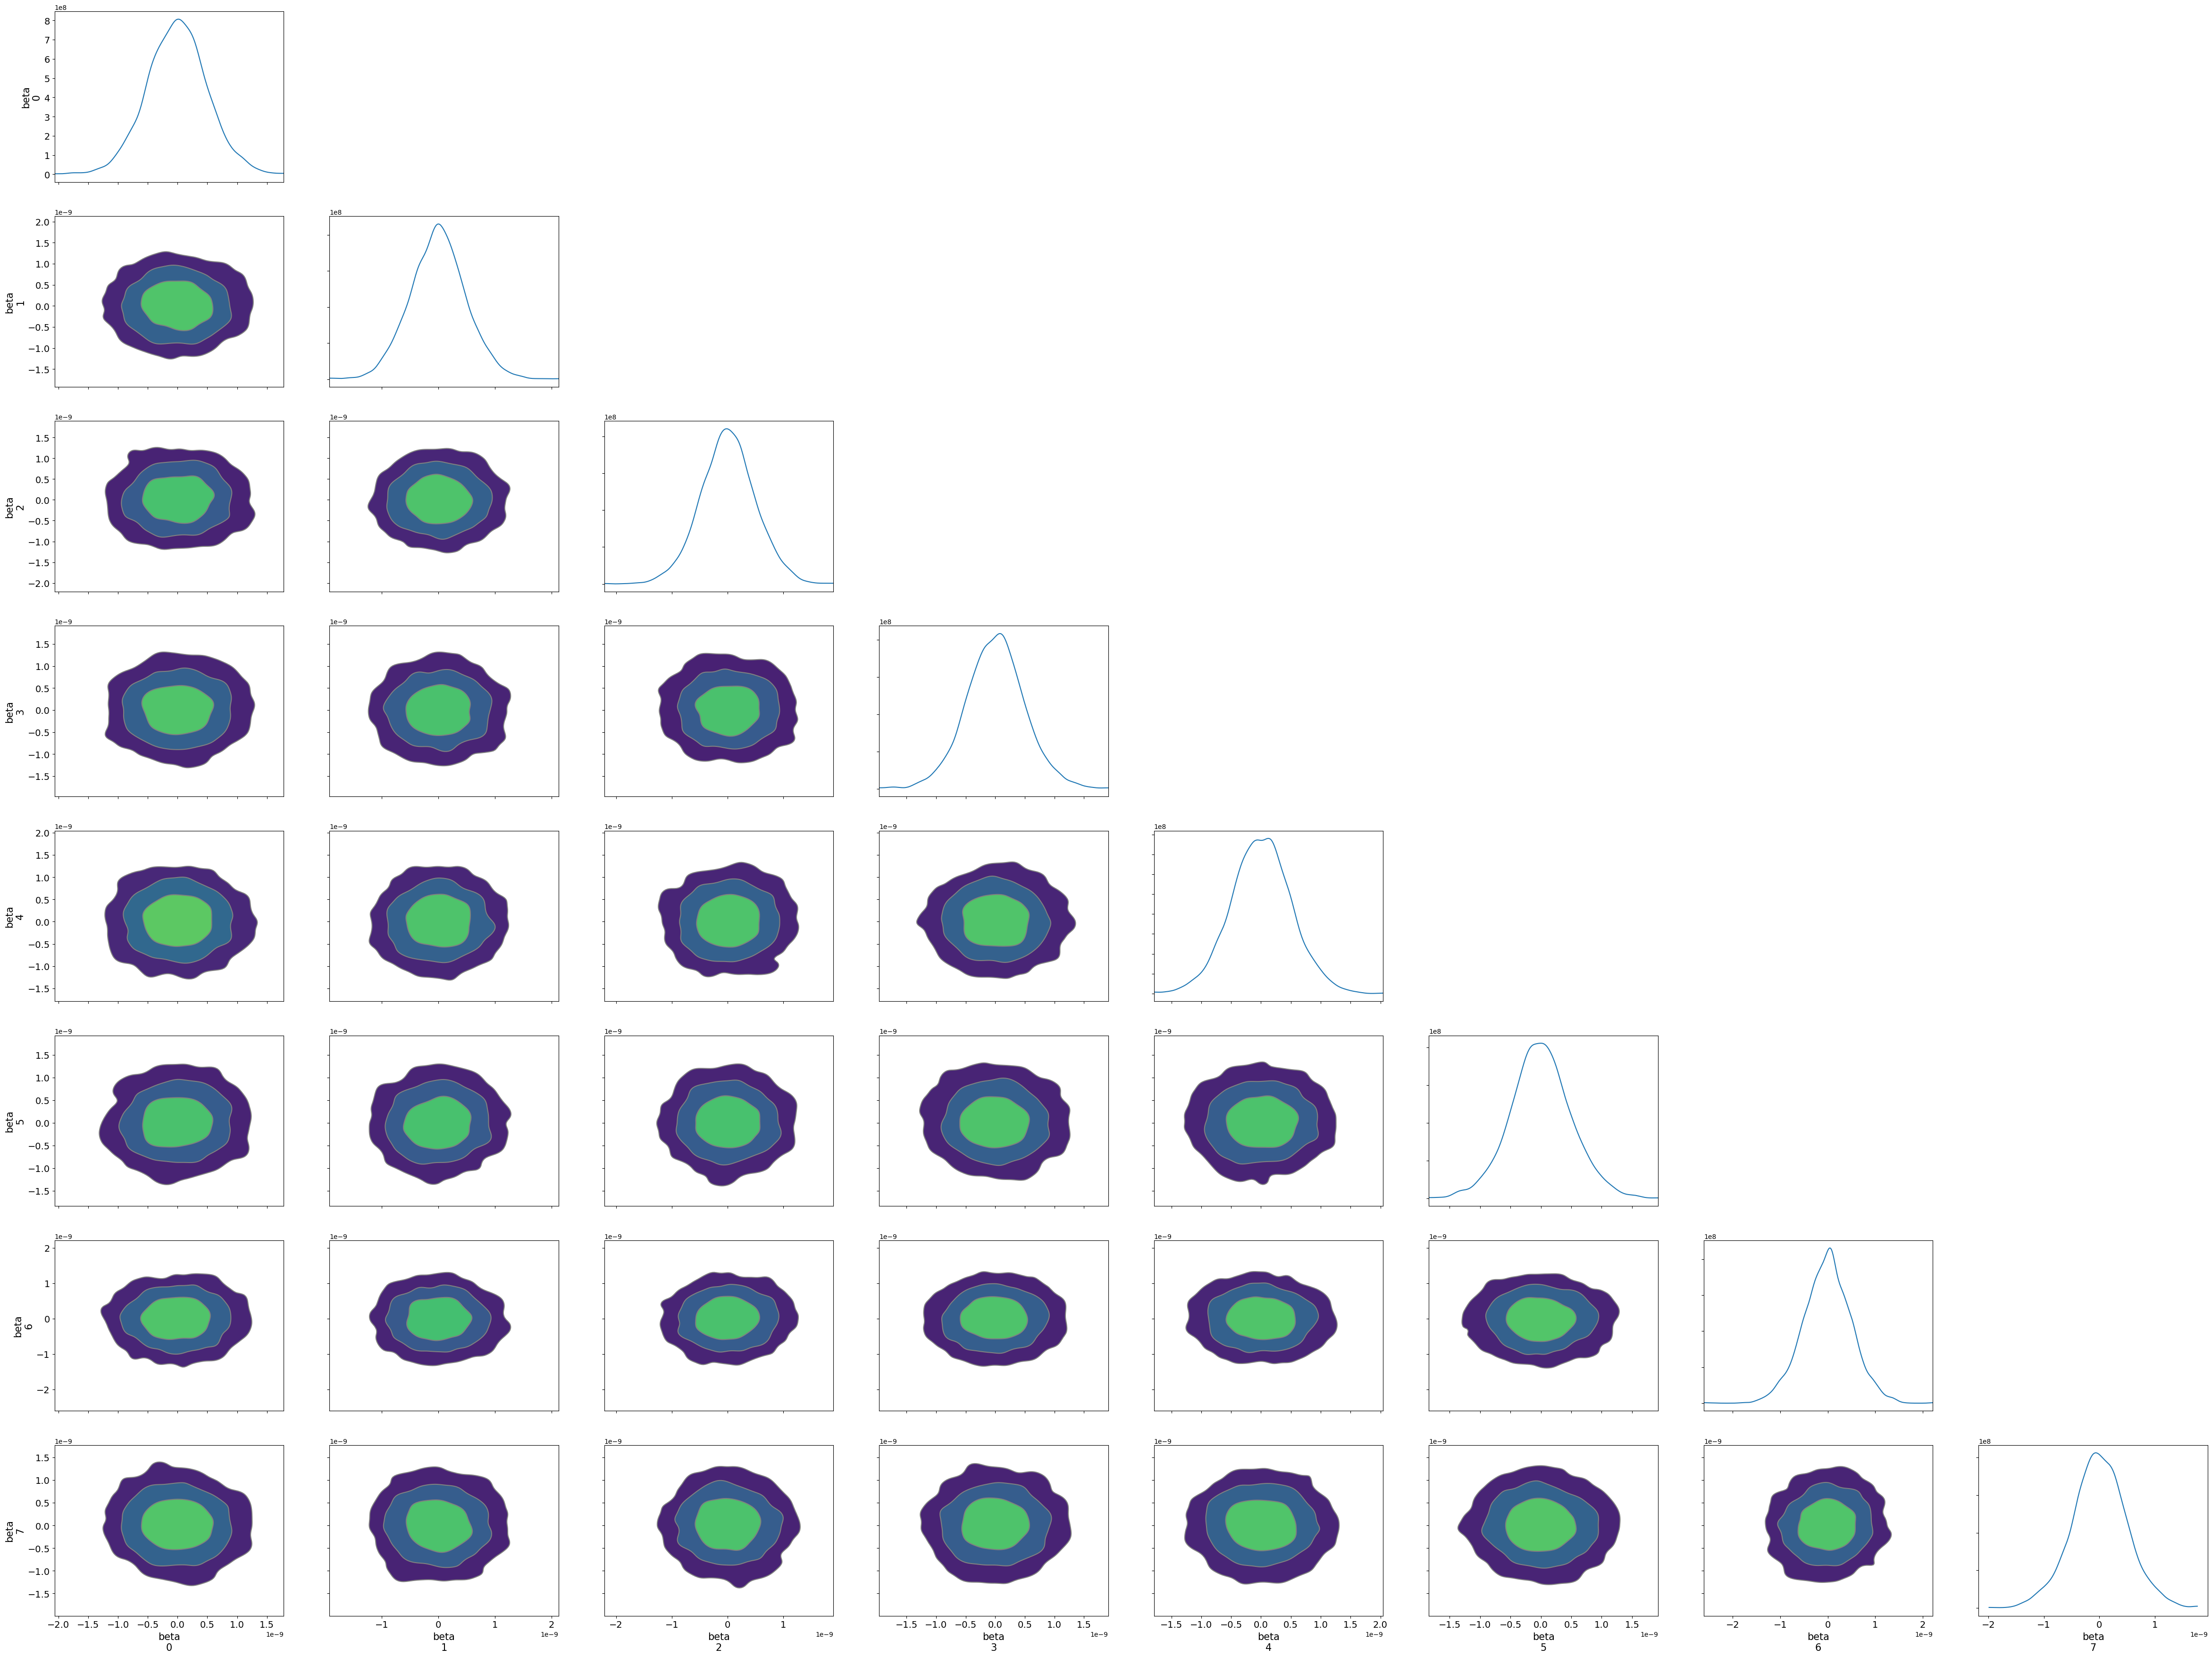

In [65]:
az.plot_pair(idata, var_names=["beta"], kind="kde", marginals=True)

---

# ACCEPTANCE RATE ANALYSIS

NUTS internally tune the step size so that the average acceptance probability is close to a target value 
$\delta=\textit{TARGET\_ACCEPT}$

We now check if the sampler actually reached this target and how much uncertainty do we have on that estimate.

In [11]:
idata.sample_stats["acceptance_rate"]

<xarray.DataArray 'acceptance_rate' (chain: 4, draw: 1000)> Size: 32kB
array([[0.94829986, 0.99950516, 0.87112246, ..., 0.97251804, 0.98215988,
        0.98376681],
       [0.96057149, 0.97679844, 0.99952063, ..., 0.87910344, 0.97402312,
        0.91873544],
       [0.993624  , 0.87472476, 0.91545928, ..., 0.98562745, 0.99700033,
        0.9999553 ],
       [0.92313678, 0.97484106, 1.        , ..., 0.95571862, 0.99945151,
        0.9942897 ]], shape=(4, 1000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

When we run HMC or NUTS, to obtain the mean acceptance rate we could compute:
$$
\mu_a = \frac{1}{N} \sum_{i=1}^N a_i
$$
where $a_i$ is the acceptance probability at iteration $i$.

But our samples are *correlated*, so $\mu_a$ is not as precise as it would be with independent samples. We want to know how much uncertainty is there in this estimate. That is the **Monte Carlo Standard Error (MCSE)**.

Instead of treating all samples as independent (wrong), we split the chain into *batches*, compute the *mean inside each batch* and treat those batch means as approximately independent. Then compute the variance across batches.

In [12]:
# Monte Carlo Standard Error (MCSE) on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    We split the sinle input chain into m batches
    Compute the mean of each batch
    Treats those batch means as approximately independent
    Estimates variance from them
    """
    x = np.asarray(x, dtype=float).ravel()   # now this is a 1D array
    n = x.size                               # number of samples
    
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size                      # m = number of batches
    
    if m < min_batches:   
        batch_size = max(1, n // min_batches) # ensures at least min_batches (default 20)
        m = n // batch_size
        
    if m < 2:  # safety check
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")

    # discards leftover samples so reshape works cleanly
    n_used = m * batch_size
    x_used = x[:n_used]
    
    # BATCH MEANS:
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)   # we obtain m means
    mcse = batch_means.std(ddof=1) / np.sqrt(m)                # computes mcse with independent approx
    
    return mcse

In [13]:
acceptance = idata.sample_stats["acceptance_rate"].to_numpy()    # Extract acceptance rates with shape: (chains, draws)
h_chain = acceptance.mean(axis=1)              # mean acceptance for each chain. shape = (chains)
diff_chain = h_chain - TARGET_ACCEPT           # how far each chain is from target
print(f"min/max h: {h_chain.min():.4f} / {h_chain.max():.4f}")   # sanity check

min/max h: 0.9370 / 0.9443


In [14]:
mcse = np.zeros(CHAINS)            # initialization
z = 1.96                           # ~95% normal quantile

for c in range(CHAINS):            # loop over chains
    h = acceptance[c].mean()       # mean acceptance for the chain
    diff = h - TARGET_ACCEPT       # how far the chain is from target
    mcse[c] = mcse_batch_means(acceptance[c])     # computes mcse for the chain
    ci95 = (diff - z*mcse[c], diff + z*mcse[c])   # cofidence interval at 95%
    print(f"chain {c}: h={h:.4f}, diff={diff:+.4f}, mcse={mcse[c]:.4f}, CI95(diff)=[{ci95[0]:.4f} : {ci95[1]:.4f}] Zero inside: {ci95[0]*ci95[1]<0}")
    

chain 0: h=0.9426, diff=-0.0074, mcse=0.0019, CI95(diff)=[-0.0112 : -0.0036] Zero inside: False
chain 1: h=0.9370, diff=-0.0130, mcse=0.0021, CI95(diff)=[-0.0171 : -0.0089] Zero inside: False
chain 2: h=0.9402, diff=-0.0098, mcse=0.0018, CI95(diff)=[-0.0133 : -0.0062] Zero inside: False
chain 3: h=0.9443, diff=-0.0057, mcse=0.0016, CI95(diff)=[-0.0089 : -0.0024] Zero inside: False


The output above prints:
* `True` → target achieved (within noise)
* `False` → systematic deviation

In [15]:
# NOW ALL CHAINS TOGETHER
h_pooled = acceptance.mean()              # overall acceptance mean
diff_pooled = h_pooled - TARGET_ACCEPT    # difference from target
mcse_pooled = mcse_batch_means(acceptance.reshape(-1))  # flatten everything: treat as one long chain
ci95_pooled = (diff_pooled - 1.96*mcse_pooled, diff_pooled + 1.96*mcse_pooled)  
print("pooled:", f" h = {h_pooled:.4f}, diff = {diff_pooled:.4f}, CI95(diff)=[{ci95_pooled[0]:.4f} : {ci95_pooled[1]:.4f}] Zero inside: {ci95_pooled[0]*ci95_pooled[1]<0}")


pooled:  h = 0.9410, diff = -0.0090, CI95(diff)=[-0.0110 : -0.0069] Zero inside: False


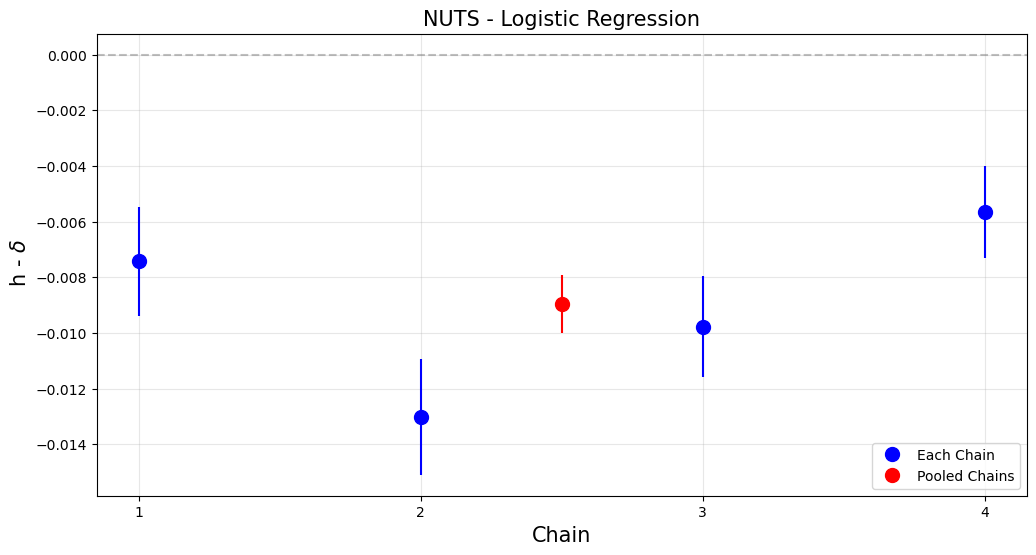

In [16]:
# plot with errorbars
fig, ax = plt.subplots(figsize=(12,6))
plt.errorbar(x = np.arange(1, CHAINS+1, 1), y = diff_chain, yerr = mcse, ls="", fmt="o", ms=10, label="Each Chain", color="blue" )
plt.errorbar(x = (CHAINS+1)/2, y = diff_pooled, yerr = mcse_pooled, ls="", fmt="o", ms=10, label="Pooled Chains", color = "red" )
plt.xlabel("Chain", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.xticks(np.arange(1, CHAINS+1, 1))
plt.legend(loc="lower right", fontsize=10)
plt.axhline(y=0.0, ls="--", color="gray", alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

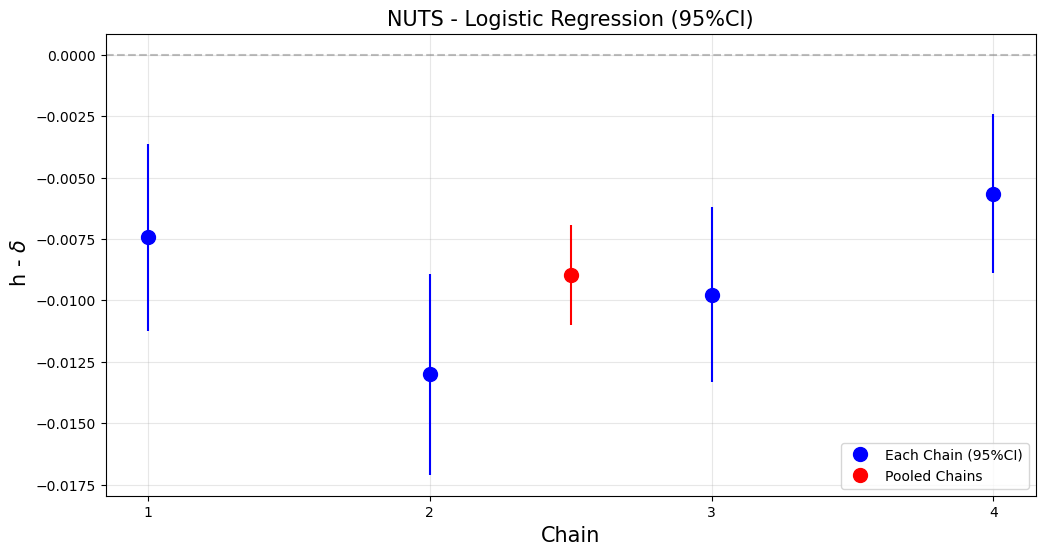

In [17]:
# plot with errorbars
fig, ax = plt.subplots(figsize=(12,6))
plt.errorbar(x = np.arange(1, CHAINS+1, 1), y = diff_chain, yerr = 1.96 * mcse, ls="", fmt="o", ms=10, label="Each Chain (95%CI)", color="blue" )
plt.errorbar(x = (CHAINS+1)/2, y = diff_pooled, yerr = 1.96 * mcse_pooled, ls="", fmt="o", ms=10, label="Pooled Chains", color = "red" )
plt.xlabel("Chain", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression (95%CI)", fontsize=15)
plt.xticks(np.arange(1, CHAINS+1, 1))
plt.legend(loc="lower right", fontsize=10)
plt.axhline(y=0.0, ls="--", color="gray", alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

Above we are checking:
$$
h - \delta \approx 0 \ ?
$$

where:
* $h$ = realized acceptance
* $\delta$ = target_accept

NUTS uses *dual averaging* to tune step size $\epsilon$, so our goal is to achieve a target acceptance rate. So this code is basically verifying if the dual averaging adaptation converged properly.

Conceptually, we are validating:
$$
\mathbb{E}[a_t] \approx \delta
$$

---

# TARGET ACCEPTANCE RATE ANALYSIS

We want to study how the **target acceptance rate** affects the efficiency of NUTS.

In HMC/NUTS, there is a key tradeoff:
* *low acceptance rate* → large step size → cheap trajectories but inaccurate
* *high acceptance rate* → small step size → accurate but expensive

So the question is: what value of target acceptance gives the best efficiency?

During tuning, $\epsilon$ is adapted so that $\mathbb{E}[\text{acceptance rate}] \approx \delta$ where $\delta$ = `target_accept`. So by varying `target_accept`, you are indirectly changing $ \epsilon \Rightarrow \text{trajectory length, accuracy, cost} $.

### APPROACH

We are looping over many $\delta$ values: $ \delta \in [0.20, 0.98]$.

For each value:

1. run NUTS
2. measure what actually happens
3. evaluate efficiency

So we compute:
1. Acceptance rate:
$$
h_c = \frac{1}{T} \sum_t a_{c,t}
\quad \text{and} \quad
h_c - \delta
$$

2. *Effective Sample Size (ESS)*, which measures statistical efficiency for $\alpha$ (scalar) plus $\beta$ (vector, 24 dims):
$$
\text{ESS} \approx \frac{N}{1 + 2\sum_k \rho_k}
$$
But ESS alone is not enough. Different runs have different computational costs. In HMC/NUTS $\text{cost} \propto \text{\# gradient evaluations}$, where each leapfrog step = 1 gradient evaluation.\
So the key metric is **ESS per gradient evaluation (unit of computation)**, and we compute:
$$
\frac{\text{ESS}}{\text{\# gradient evaluations}}
$$
This is the right metric because:
    * small $\epsilon$ (high acceptance) $\Rightarrow $ high ESS (good mixing) but many steps → expensive
    * large $\epsilon$ (low acceptance) $\Rightarrow $ cheap steps but poor mixing → low ESS

    So the tradeoff is $\text{efficiency} = \frac{\text{ESS}}{\text{cost}}$


Then:
* average (or take minimum, more conservative) over chains
* average (or take minimum, more conservative) over parameters
to get a single scalar efficiency measure for each $\delta$ value.

---

### RESULTS

We will end up with:
* x-axis: target acceptance $\delta$
* y-axis: efficiency (ESS per gradient)

And we want to see where is the maximum. From theory (and the NUTS paper) optimal $\delta$ is typically around $ 0.6 \text{ to } 0.9 $. We should see a peak in efficiency.

In [27]:
# In function of the target acceptance:
prior_mean = 0                              # Mean of the Gaussian prior for parameters
prior_var = 100                             # Variance of the Gaussian prior

# Choose the ESS metric method:
metric_choice = "paper"                     # "paper" (mean vs second central moment) or "modern" (bulk vs tail)

# Choose how to aggregate across dimensions at the very end:
aggregation_choice = "min"                  # "min" (strict paper methodology) or "mean" (average across dimensions)

-------------FIX MODEL---------------

In [28]:
# ======================= MODEL DEFINITION =================
# We define the model logic inside a function so we can reuse it for both baseline and experiment runs
def create_model(X, y):
    with pm.Model() as model:  
        X_data = pm.Data("X", X)  # Register feature matrix X as shared data inside the model
        y_data = pm.Data("y", y) 
        
        # Priors
        alpha = pm.Normal("alpha", mu=prior_mean, sigma=np.sqrt(prior_var))  
        beta  = pm.Normal("beta", mu=prior_mean, sigma=np.sqrt(prior_var), shape=X_data.shape[1]) 

        # eta_i = alpha + x_i * beta
        eta = alpha + pt.dot(X_data, beta)  # Linear predictor

        # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
        loglike = -pt.sum(pt.log1p(pt.exp(-y_data * eta)))  

        pm.Potential("likelihood", loglike)  # Add custom log-likelihood term to the model
    return model

In [29]:
# =========================== MODEL CREATION ======================
my_model = create_model(X_int, y)

In [30]:
# ======================= BASELINE RUN (50k Samples) =================
if metric_choice == "paper":
    print("Running baseline 50,000 samples to compute mu_true for the second central moment...")
    with my_model:
        baseline_idata = pm.sample(
            draws=50000, 
            tune=1000, 
            chains=1,                       # The paper runs a single long chain for the baseline
            target_accept=0.5,              # delta = 0.5 as specified in the paper
            random_seed=42,
            nuts_sampler="pymc",
            progressbar=True,
            max_treedepth = 14
        )
    # Extract the highly precise true means (mu_true)
    mu_true_alpha = baseline_idata.posterior["alpha"].mean().values
    mu_true_beta = baseline_idata.posterior["beta"].mean(dim=["chain", "draw"]).values
    print("Baseline complete. mu_true calculated.")

Initializing NUTS using jitter+adapt_diag...


Running baseline 50,000 samples to compute mu_true for the second central moment...


Sequential sampling (1 chains in 1 job)
NUTS: [alpha, beta]


Output()

Sampling 1 chain for 1_000 tune and 50_000 draw iterations (1_000 + 50_000 draws total) took 54 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Baseline complete. mu_true calculated.


In [31]:
def acc_rate_sweep( model, acceptance_rate_list, repetitions, sample_dict ):
    
    results = pd.DataFrame(columns=["Delta", "Diff", "MCSE", "Min", "Mean", "Bulk Min", "Bulk Mean", "Grad Evals"])
    seed_offset = 0
    bins = np.arange(0, sample_dict["max_treedepth"]+2, 1) - 0.5
    # Store the counts of the reached depth: one row for each value of the target acceptance and one column for each frequency
    depth_counts = np.zeros(shape=(len(acceptance_rate_list), len(bins)-1 ))
    
    for i, target_accept in (enumerate(acceptance_rate_list)):
        print(f"Running Set {i+1}/{len(acceptance_rate_list)}")
        for _ in tqdm(range(repetitions)):
            with model:
                idata = pm.sample(  
                draws = sample_dict["draws"],     # number of posterior samples (after warmup)
                tune = sample_dict["tune"],      # number of warmup steps
                chains = sample_dict["chains"], 
                target_accept = target_accept,
                random_seed = sample_dict["start_seed"] + seed_offset,     # different seed for each run
                max_treedepth = sample_dict["max_treedepth"],
                progressbar = False,    # disable progress bar
                quiet = True,           # suppress sampler messages
                nuts_sampler = "pymc",  # use PyMC's NUTS implementation        
            )
            seed_offset += 1

            # extract acceptance rates and put them together for the same experiment
            acceptance = idata.sample_stats["acceptance_rate"].to_numpy()  
            h_chain = acceptance.reshape(-1,).mean()     # mean acceptance per experiment
            diff_chain = h_chain - target_accept  # deviation from target δ exeriment
            
            mcse = np.zeros(sample_dict["chains"]) # initialize MCSE array (per chain)
            # Loop over chains (Only for MCSE/Acceptance stats)
            for c in range(sample_dict["chains"]): 
                mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain

            # 2. Combine the MCSE error bars properly for independent chains
            combined_mcse = np.sqrt( (mcse**2).sum() )/ sample_dict["chains"]

            # ============== Computing ESS and Gradient Evaluations =============
    
            # Get the number of steps (POST WARM UP) 
            n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape: (chains, draws)        
            
            # In the paper, ESS is normalized by the TOTAL amount of gradient evaluations across all samples
            total_grad_evals = n_steps.sum()  # Scalar: total gradient evaluations across all chains & draws

            # Like in the paper
            # 1. Compute Mean ESS
            ess_mean = az.ess(idata, method="mean")
            
            # 2. Compute Second Central Moment ESS
            # FIX: Keep data as an xarray Dataset so ArviZ preserves named dimensions for the 24D beta
            sq_diff_ds = xr.Dataset({
                "alpha": (idata.posterior["alpha"] - mu_true_alpha)**2,
                "beta": (idata.posterior["beta"] - mu_true_beta)**2
            })
            ess_var = az.ess(sq_diff_ds, method="mean")

            # 3. Take the minimum between mean and variance for each dimension
            # Both ess_mean and ess_var are now clean xarray Datasets, so .values extracts the array properly
            ess_alpha_min = np.minimum(ess_mean["alpha"].values, ess_var["alpha"].values)
            ess_beta_min = np.minimum(ess_mean["beta"].values, ess_var["beta"].values)

             # Normalize by the total gradient evaluations
            # Results are now a scalar (for alpha) and an array of 24 (for beta), evaluated ACROSS all chains
            ess_per_grad_alpha = ess_alpha_min / total_grad_evals  
            ess_per_grad_beta = ess_beta_min / total_grad_evals

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_beta = np.mean(ess_per_grad_beta)
            ESS_PER_GRAD_MEAN = np.mean([ess_per_grad_alpha, mean_ess_grad_beta]) 

            # Strict paper methodology: take the absolute worst-case dimension
            all_ess_per_grad = np.append(ess_per_grad_alpha, ess_per_grad_beta)
            ESS_PER_GRAD_MIN = np.min(all_ess_per_grad)

             # Compute Bulk ESS natively
            ess_bulk = az.ess(idata, method="bulk")

            ess_alpha_bulk = ess_bulk["alpha"].values
            ess_beta_bulk = ess_bulk["beta"].values

            ess_per_grad_alpha_bulk = ess_alpha_bulk / total_grad_evals  
            ess_per_grad_beta_bulk = ess_beta_bulk / total_grad_evals 

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_beta_bulk = np.mean(ess_per_grad_beta_bulk)
            ESS_PER_GRAD_MEAN_bulk = np.mean([ess_per_grad_alpha_bulk, mean_ess_grad_beta_bulk]) 

            # Strict paper methodology: take the absolute worst-case dimension
            all_ess_per_grad_bulk = np.append(ess_per_grad_alpha_bulk, ess_per_grad_beta_bulk)
            ESS_PER_GRAD_MIN_bulk = np.min(all_ess_per_grad_bulk)

            # Save results to dataframe
            tmp= pd.DataFrame({"Delta" : target_accept,
                            "Diff"  : diff_chain,
                            "MCSE"  : combined_mcse,
                            "Min"   : ESS_PER_GRAD_MIN,
                            "Mean"  : ESS_PER_GRAD_MEAN,
                            "Bulk Min": ESS_PER_GRAD_MIN_bulk,
                            "Bulk Mean": ESS_PER_GRAD_MEAN_bulk,
                            "Grad Evals": total_grad_evals
                           }, index = [0])
            
            results = pd.concat([results, tmp], ignore_index=True)

            depth = idata.sample_stats["tree_depth"].to_numpy().ravel()  # flatten chains+draws
            curr_counts, egdes = np.histogram(depth, bins = bins)
            depth_counts[i,:] += curr_counts
            
    return results, depth_counts

In [32]:
delta_list = np.arange(0.25, 0.99, 0.05)
reps = 10
sample_settings = {"draws": 1000,
                   "tune" : 1000,
                   "chains": 4,
                   "start_seed": 2026,
                   "max_treedepth": 14
                  }

start_time = time.perf_counter()   # debug
df, depths = acc_rate_sweep(my_model, delta_list, reps, sample_settings)
# DEBUG:
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time elapsed: {elapsed_time:.4f} seconds")

Running Set 1/15


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_7352/3785195950.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, tmp], ignore_index=True)


Running Set 2/15


  0%|          | 0/10 [00:00<?, ?it/s]

...

Running Set 14/15


  0%|          | 0/10 [00:00<?, ?it/s]

Running Set 15/15


  0%|          | 0/10 [00:00<?, ?it/s]

Time elapsed: 875.0368 seconds


In [33]:
df.head(15)

,Delta,Diff,MCSE,Min,Mean,Bulk Min,Bulk Mean,Grad Evals
0,0.25,0.029445,0.004252,0.027625,0.040040,0.062097,0.073150,30948.0
1,0.25,-0.030632,0.004447,0.019117,0.030757,0.027831,0.045188,31464.0
2,0.25,-0.027710,0.003720,0.020524,0.034952,0.026996,0.044727,30884.0
3,0.25,-0.136328,0.002917,0.009018,0.013484,0.008908,0.013943,31132.0
4,0.25,-0.090353,0.003279,0.012941,0.021236,0.020277,0.026476,30764.0
5,0.25,0.006098,0.003748,0.028578,0.041564,0.036977,0.066456,30584.0
6,0.25,-0.154472,0.002569,0.010657,0.015180,0.010629,0.015447,33176.0
7,0.25,-0.054943,0.003841,0.014705,0.023641,0.026589,0.033956,30700.0
8,0.25,-0.038839,0.003678,0.021009,0.032509,0.023699,0.037832,32302.0
9,0.25,-0.061105,0.003289,0.015417,0.023870,0.020371,0.025024,31324.0


# RESULTS VISUALIZATION

## ESS

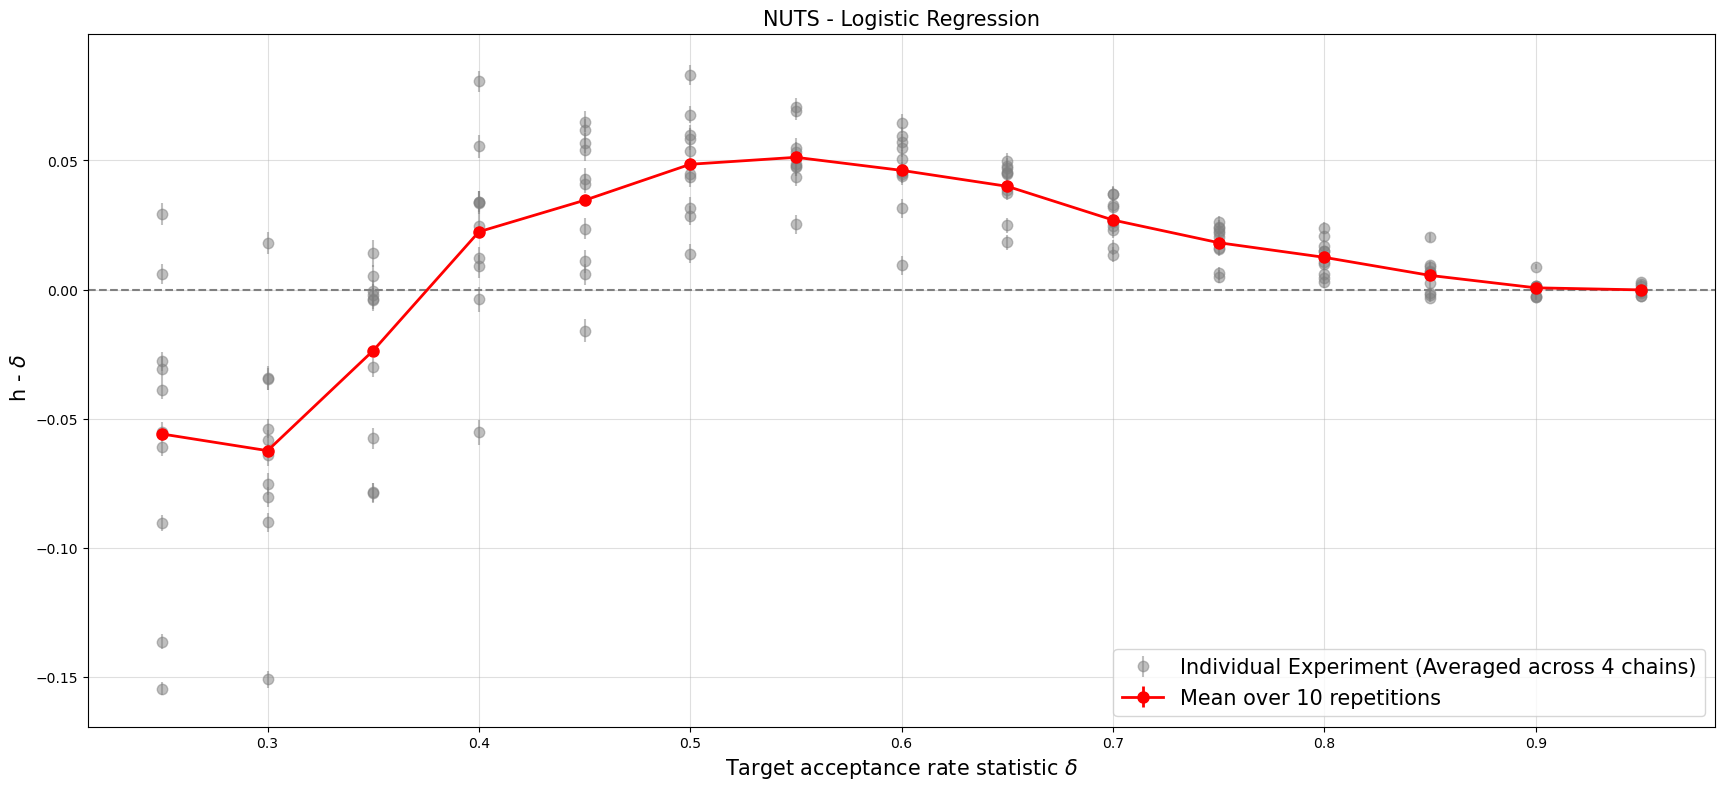

In [34]:
x_in_graph = df["Delta"].values

# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.errorbar(
    x = x_in_graph, 
    y = df["Diff"], 
    yerr = df["MCSE"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.errorbar(x = delta_list,
            y = df.groupby(by="Delta").mean()["Diff"],
            yerr = df.groupby(by="Delta")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / reps ),
            ls = "-",
            marker = "o",
            ms = 8,
            label = f"Mean over {reps} repetitions",
            color="red",
            lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

## ESS / Grad

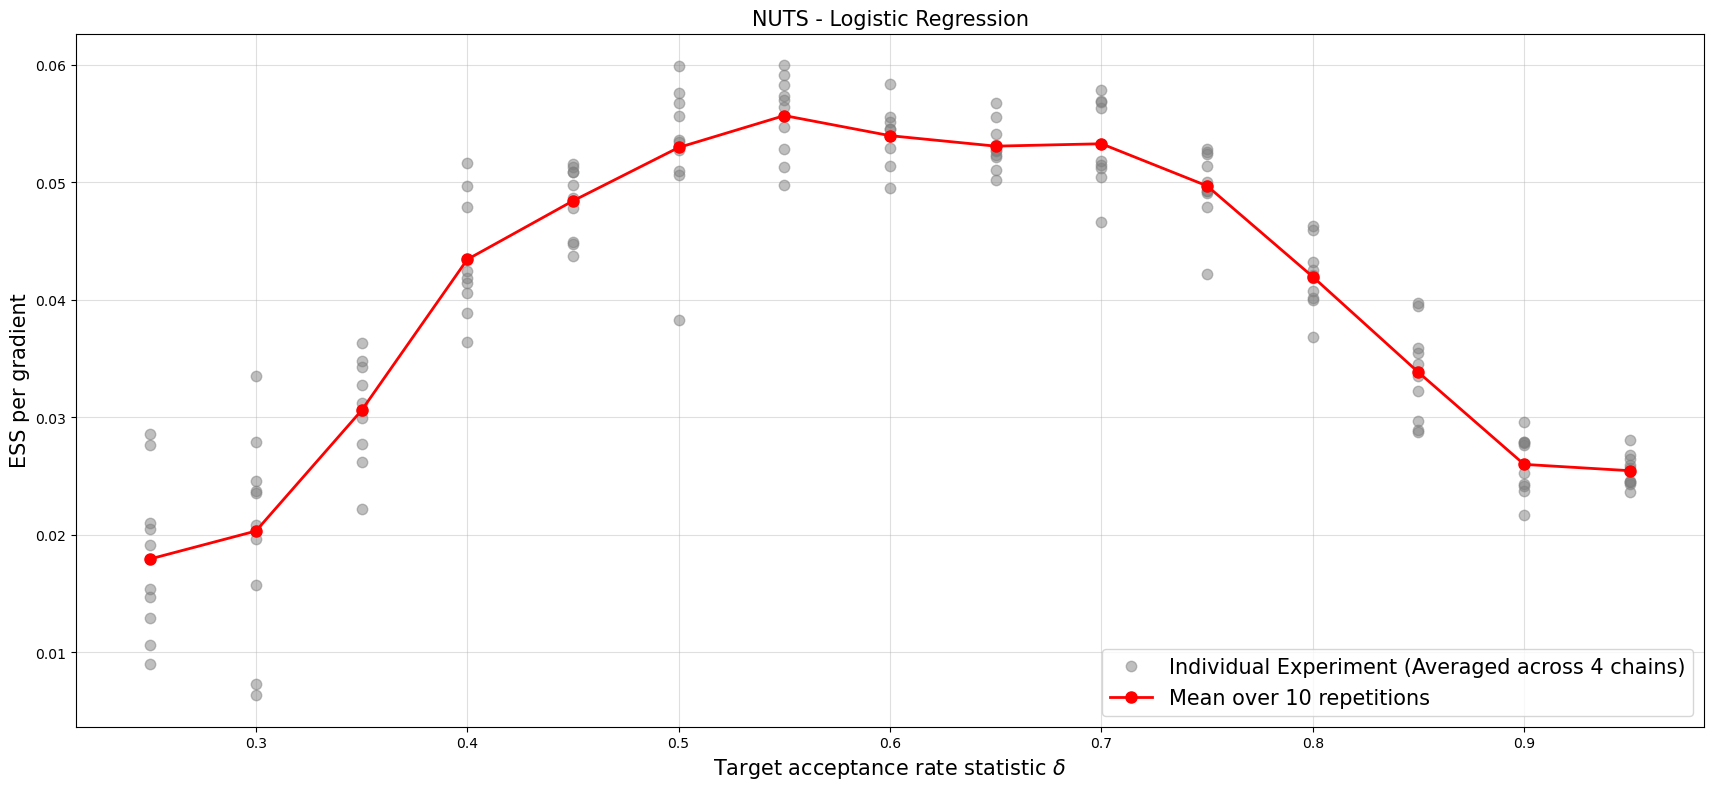

In [36]:
# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.plot(
    x_in_graph, 
    df["Min"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.plot(delta_list,
        df.groupby(by="Delta").mean()["Min"],
        ls = "-",
        marker = "o",
        ms = 8,
        label = f"Mean over {reps} repetitions",
        color="red",
        lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel("ESS per gradient", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.grid(alpha=0.4)
plt.show()

## Counts

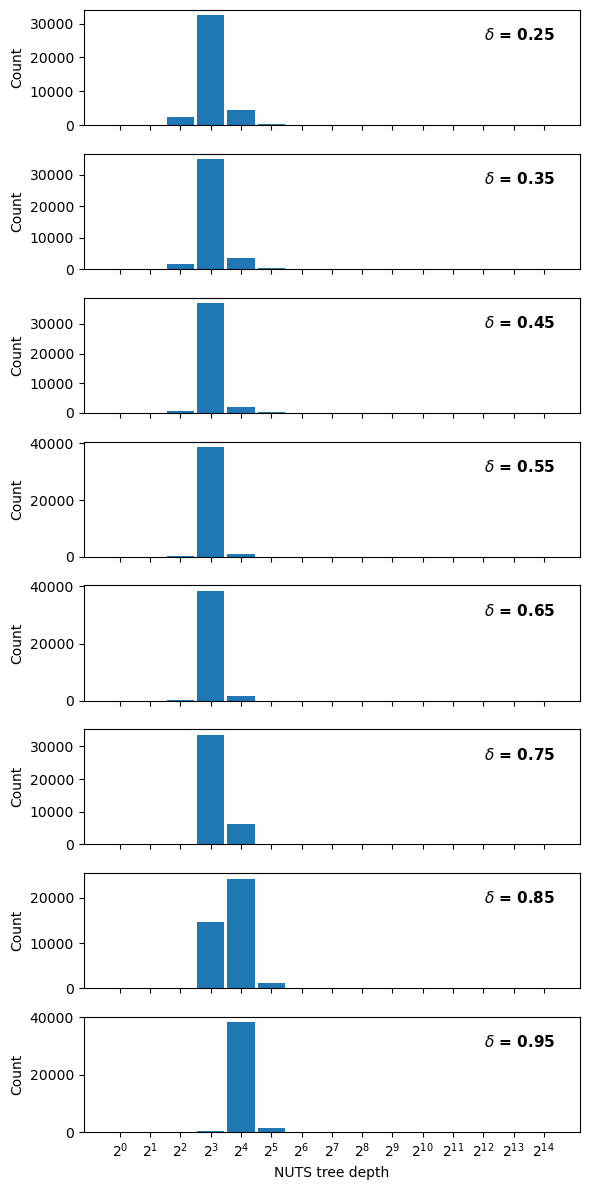

In [37]:
# Your index selection array
show_this_delta = np.arange(0, len(delta_list), 2, dtype="int")

# 1. Calculate number of vertical rows
n_rows = len(show_this_delta)

# 2. Create a single vertical column grid
# Each panel gets a height of 2.5 inches (adjust as you like)
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 1.5 * n_rows), sharex=True)

# Handle the edge case where show_this_delta has only 1 element
if n_rows == 1:
    axes = [axes]

x_ticks = np.arange(0, sample_settings["max_treedepth"] + 1, 1)
x_labels = [fr"$2^{{{k}}}$" for k in range(sample_settings["max_treedepth"] + 1)]

# 3. Populate the vertical grid
for plot_idx, i in enumerate(show_this_delta):
    ax = axes[plot_idx]
    
    # Draw the bar chart
    ax.bar(x_ticks, depths[i], width=0.9, color="C0", edgecolor="none")
    
    # Always set ticks, but sharex=True will automatically hide labels for upper plots
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    
    # Y-Label for each specific panel
    ax.set_ylabel("Count")
    
    # Place delta text directly inside the plot panel (top right)
    ax.text(
        0.95, 0.85, 
        fr"$\delta$ = {delta_list[i]:.2f}", 
        transform=ax.transAxes, 
        horizontalalignment="right", 
        verticalalignment="top",
        fontsize=11,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
    )

# 4. Set the X-label only on the very last (bottom) subplot panel
axes[-1].set_xlabel("NUTS tree depth")

plt.tight_layout()
plt.show()

In [38]:
df.to_pickle("NUTS_HLR.pkl")

# HMC Version

In [39]:
def acc_rate_sweep_HMC( model, acceptance_rate_list, repetitions, sample_dict ):
    
    results = pd.DataFrame(columns=["Delta", "Path Length", "Diff", "MCSE", "Min", "Mean", "Bulk Min", "Bulk Mean", "Grad Evals"])
    seed_offset = 0

    for path_l in sample_dict["path_length"]:
        print(f"------ Testing path length {path_l:.2f}------ ")
        for i, target_accept in (enumerate(acceptance_rate_list)):
            print(f"Running Set {i+1}/{len(acceptance_rate_list)}")
            for _ in tqdm(range(repetitions)):
                with model:
                    idata = pm.sample(  
                    draws = sample_dict["draws"],     # number of posterior samples (after warmup)
                    tune = sample_dict["tune"],      # number of warmup steps
                    chains = sample_dict["chains"],
                    # Changing from NUTS to HMC by defining the hyperparameters
                    step = pm.HamiltonianMC(target_accept = target_accept,   # acceptance probability to adapt step size toward
                                            path_length = path_l,            # total trajectory length
                                       ),
                    random_seed = sample_dict["start_seed"] + seed_offset,     # different seed for each run
                    progressbar = False,    # disable progress bar
                    quiet = True           # suppress sampler messages  
                )
                seed_offset += 1
    
                # extract acceptance rates and put them together for the same experiment: Here accepted is a bool for each step
                acceptance = idata.sample_stats["accepted"].to_numpy()  
                h_chain = acceptance.reshape(-1,).mean()     # mean acceptance per experiment
                diff_chain = h_chain - target_accept  # deviation from target δ exeriment
                
                mcse = np.zeros(sample_dict["chains"]) # initialize MCSE array (per chain)
                # Loop over chains (Only for MCSE/Acceptance stats)
                for c in range(sample_dict["chains"]): 
                    mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain
    
                # 2. Combine the MCSE error bars properly for independent chains
                combined_mcse = np.sqrt( (mcse**2).sum() )/ sample_dict["chains"]
    
                # ============== Computing ESS and Gradient Evaluations =============
        
                # Get the number of steps (POST WARM UP) 
                n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape: (chains, draws)        
                
                # In the paper, ESS is normalized by the TOTAL amount of gradient evaluations across all samples
                total_grad_evals = n_steps.sum()  # Scalar: total gradient evaluations across all chains & draws
    
                # Like in the paper
                # 1. Compute Mean ESS
                ess_mean = az.ess(idata, method="mean")
                
                # 2. Compute Second Central Moment ESS
                # FIX: Keep data as an xarray Dataset so ArviZ preserves named dimensions for the 24D beta
                sq_diff_ds = xr.Dataset({
                    "alpha": (idata.posterior["alpha"] - mu_true_alpha)**2,
                    "beta": (idata.posterior["beta"] - mu_true_beta)**2
                })
                ess_var = az.ess(sq_diff_ds, method="mean")
    
                # 3. Take the minimum between mean and variance for each dimension
                # Both ess_mean and ess_var are now clean xarray Datasets, so .values extracts the array properly
                ess_alpha_min = np.minimum(ess_mean["alpha"].values, ess_var["alpha"].values)
                ess_beta_min = np.minimum(ess_mean["beta"].values, ess_var["beta"].values)
    
                 # Normalize by the total gradient evaluations
                # Results are now a scalar (for alpha) and an array of 24 (for beta), evaluated ACROSS all chains
                ess_per_grad_alpha = ess_alpha_min / total_grad_evals  
                ess_per_grad_beta = ess_beta_min / total_grad_evals
    
                # Final Aggregation across dimensions to get a single number
                # Average across dimensions
                mean_ess_grad_beta = np.mean(ess_per_grad_beta)
                ESS_PER_GRAD_MEAN = np.mean([ess_per_grad_alpha, mean_ess_grad_beta]) 
    
                # Strict paper methodology: take the absolute worst-case dimension
                all_ess_per_grad = np.append(ess_per_grad_alpha, ess_per_grad_beta)
                ESS_PER_GRAD_MIN = np.min(all_ess_per_grad)
    
                 # Compute Bulk ESS natively
                ess_bulk = az.ess(idata, method="bulk")
    
                ess_alpha_bulk = ess_bulk["alpha"].values
                ess_beta_bulk = ess_bulk["beta"].values
    
                ess_per_grad_alpha_bulk = ess_alpha_bulk / total_grad_evals  
                ess_per_grad_beta_bulk = ess_beta_bulk / total_grad_evals 
    
                # Final Aggregation across dimensions to get a single number
                # Average across dimensions
                mean_ess_grad_beta_bulk = np.mean(ess_per_grad_beta_bulk)
                ESS_PER_GRAD_MEAN_bulk = np.mean([ess_per_grad_alpha_bulk, mean_ess_grad_beta_bulk]) 
    
                # Strict paper methodology: take the absolute worst-case dimension
                all_ess_per_grad_bulk = np.append(ess_per_grad_alpha_bulk, ess_per_grad_beta_bulk)
                ESS_PER_GRAD_MIN_bulk = np.min(all_ess_per_grad_bulk)
    
                # Save results to dataframe
                tmp= pd.DataFrame({"Delta" : target_accept,
                                "Path Length": path_l,
                                "Diff"  : diff_chain,
                                "MCSE"  : combined_mcse,
                                "Min"   : ESS_PER_GRAD_MIN,
                                "Mean"  : ESS_PER_GRAD_MEAN,
                                "Bulk Min": ESS_PER_GRAD_MIN_bulk,
                                "Bulk Mean": ESS_PER_GRAD_MEAN_bulk,
                                "Grad Evals": total_grad_evals
                               }, index = [0])
                
                results = pd.concat([results, tmp], ignore_index=True)
            
    return results

In [40]:
delta_list_HMC = np.arange(0.25, 0.99, 0.1)
path_L_for_ESS = [0.03, 0.044, 0.065, 0.097, 0.14, 0.21, 0.31]
path_L_for_h_delta = [0.044, 0.097, 0.21, 0.46, 1.0]
path_length_list = np.union1d(path_L_for_ESS, path_L_for_h_delta)
reps_HMC = 10
sample_settings_HMC = {"draws": 1000,
                   "tune" : 1000,
                   "chains": 4,
                   "start_seed": 2026,
                   "path_length": path_length_list

                      }
start_time = time.perf_counter()   # debug
df_HMC = acc_rate_sweep_HMC( my_model, delta_list_HMC, reps_HMC, sample_settings_HMC )
# DEBUG:
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time elapsed: {elapsed_time:.4f} seconds")

------ Testing path length 0.05------ 
Running Set 1/8


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_7352/2482245365.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, tmp], ignore_index=True)


Running Set 2/8


  0%|          | 0/10 [00:00<?, ?it/s]

...

Running Set 7/8


  0%|          | 0/10 [00:00<?, ?it/s]

Running Set 8/8


  0%|          | 0/10 [00:00<?, ?it/s]

Time elapsed: 1707.9671 seconds


In [41]:
df_HMC.head(15)

,Delta,Path Length,Diff,MCSE,Min,Mean,Bulk Min,Bulk Mean,Grad Evals
0,0.25,0.05,-0.07575,0.008466,0.005906,0.032317,0.006097,0.033182,4000
1,0.25,0.05,-0.12725,0.007019,0.005813,0.023828,0.005634,0.023747,4000
2,0.25,0.05,-0.09225,0.007375,0.007070,0.026166,0.006966,0.026145,4000
3,0.25,0.05,-0.12500,0.005842,0.005734,0.016897,0.005295,0.017262,4000
4,0.25,0.05,-0.09550,0.006497,0.005144,0.021128,0.004743,0.021831,4000
5,0.25,0.05,-0.11700,0.005869,0.004386,0.017106,0.004492,0.017790,4000
6,0.25,0.05,-0.08325,0.008670,0.005080,0.022505,0.005190,0.022900,4000
7,0.25,0.05,-0.08050,0.007811,0.004182,0.032655,0.004249,0.032774,4000
8,0.25,0.05,-0.08150,0.008568,0.004721,0.020324,0.004774,0.020812,4000
9,0.25,0.05,-0.06275,0.009146,0.005372,0.020351,0.005421,0.021422,4000


## Accept rate

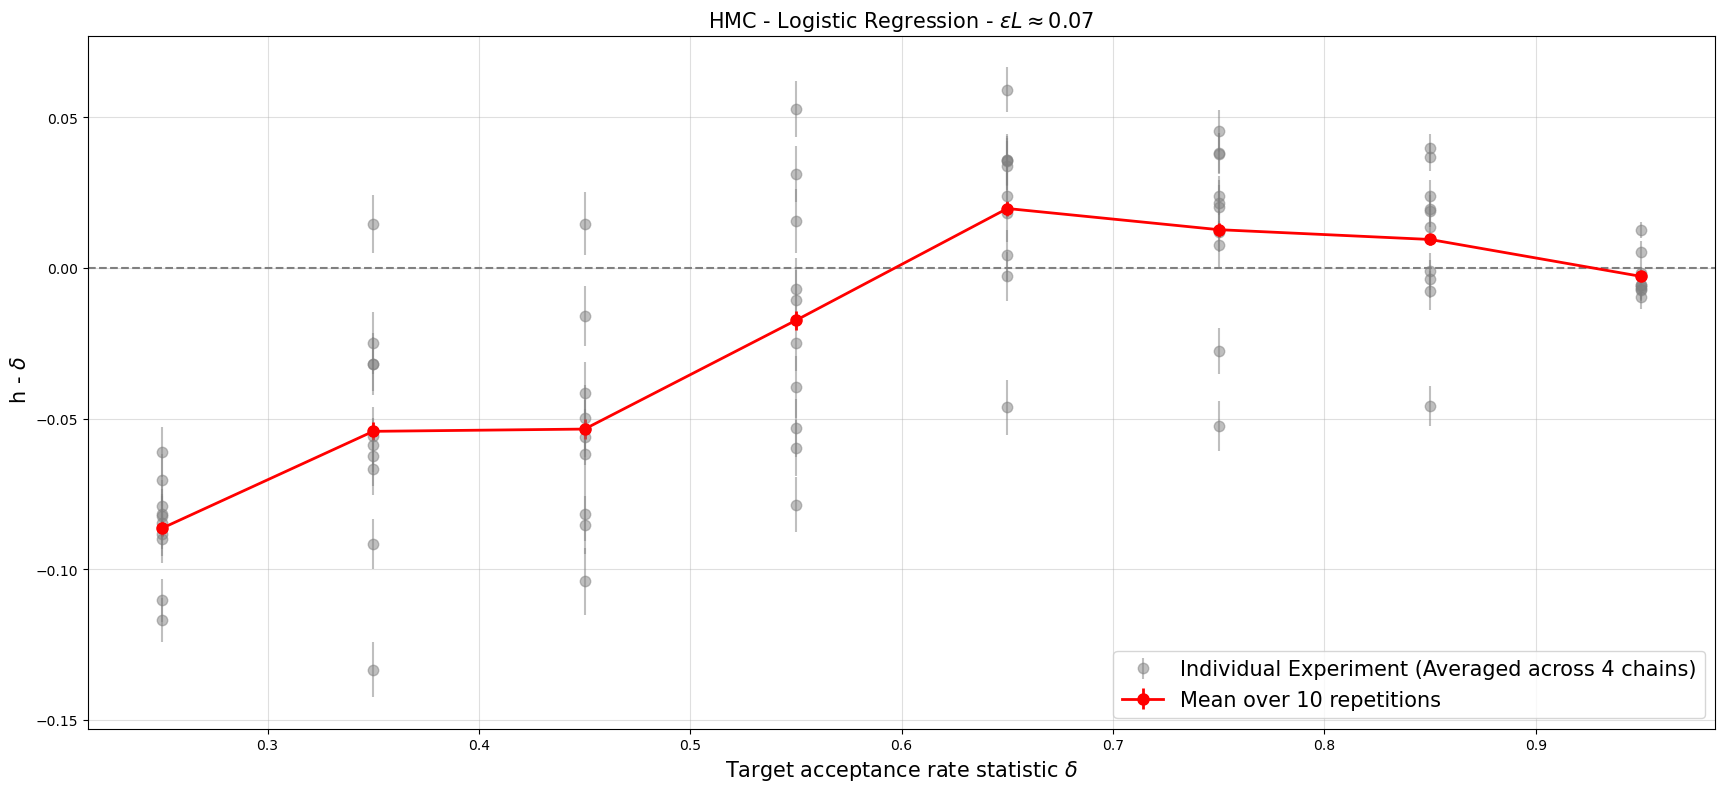

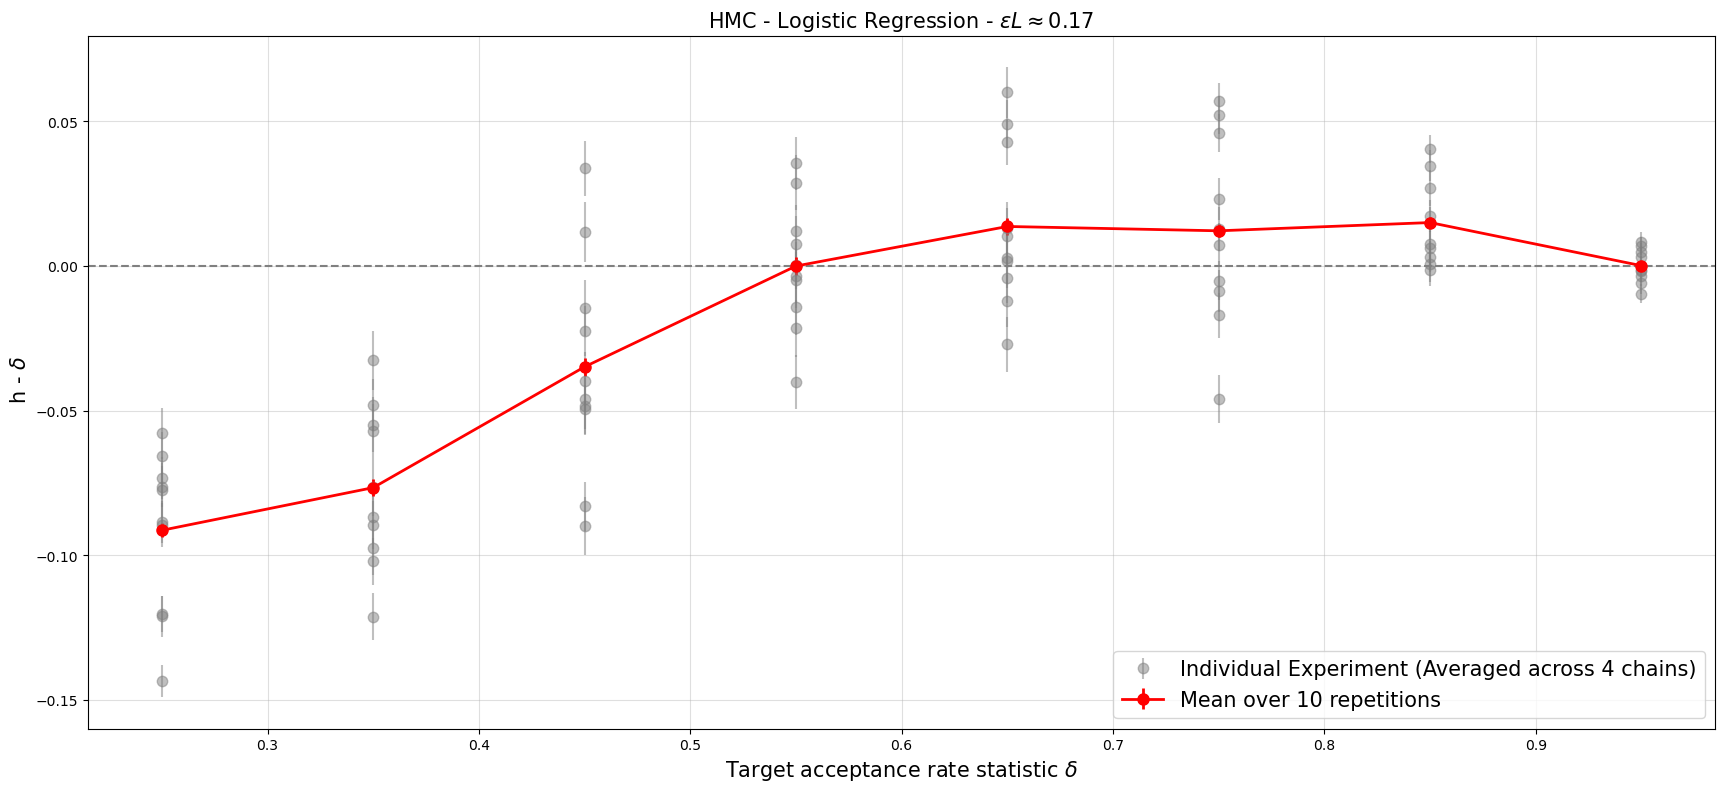

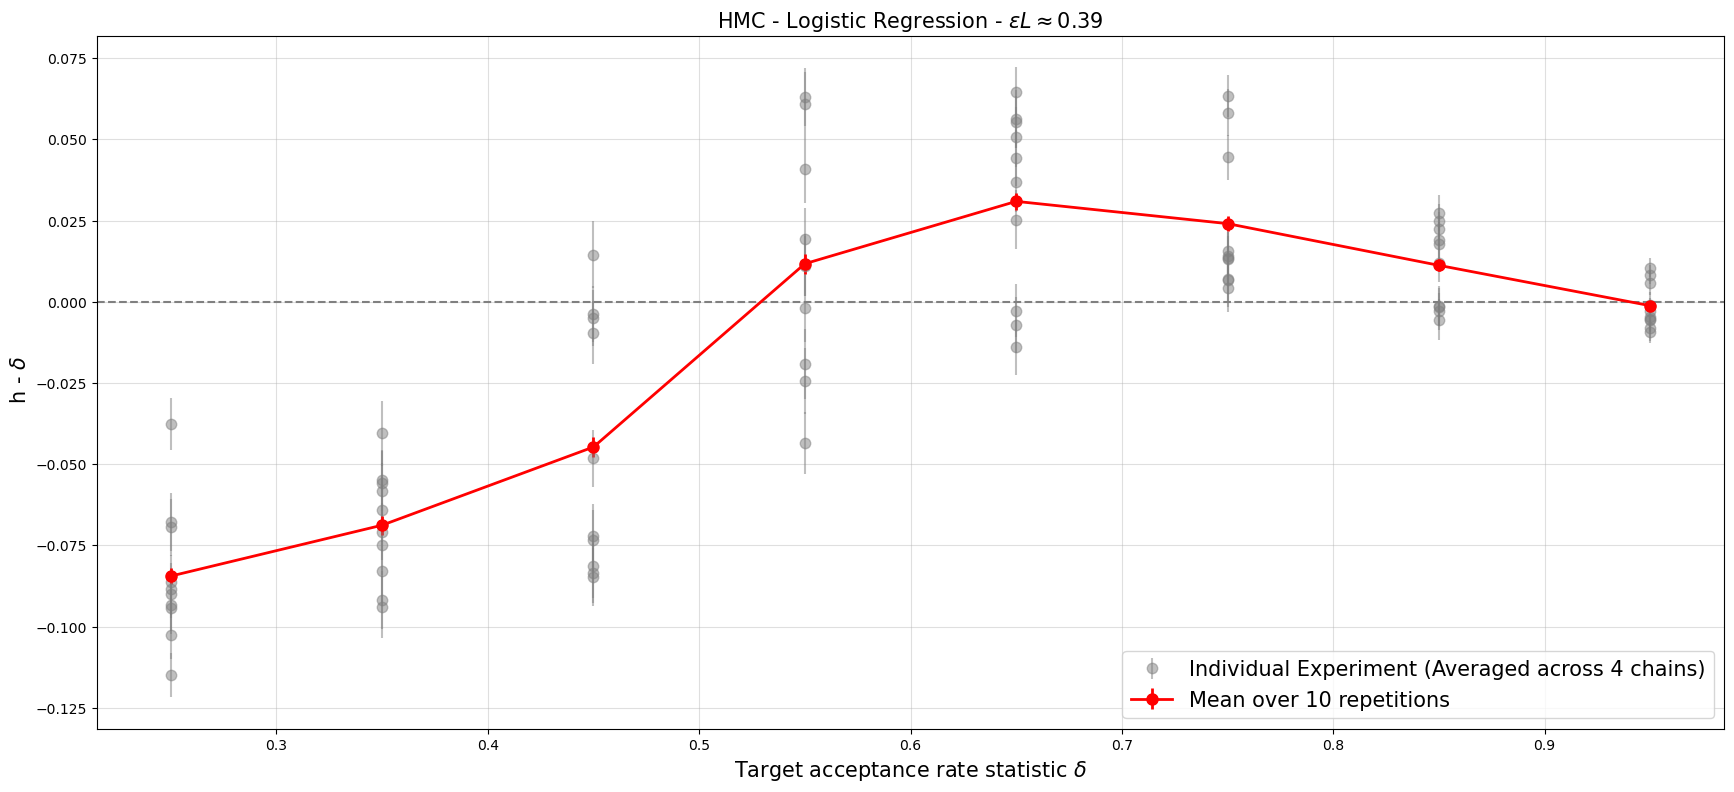

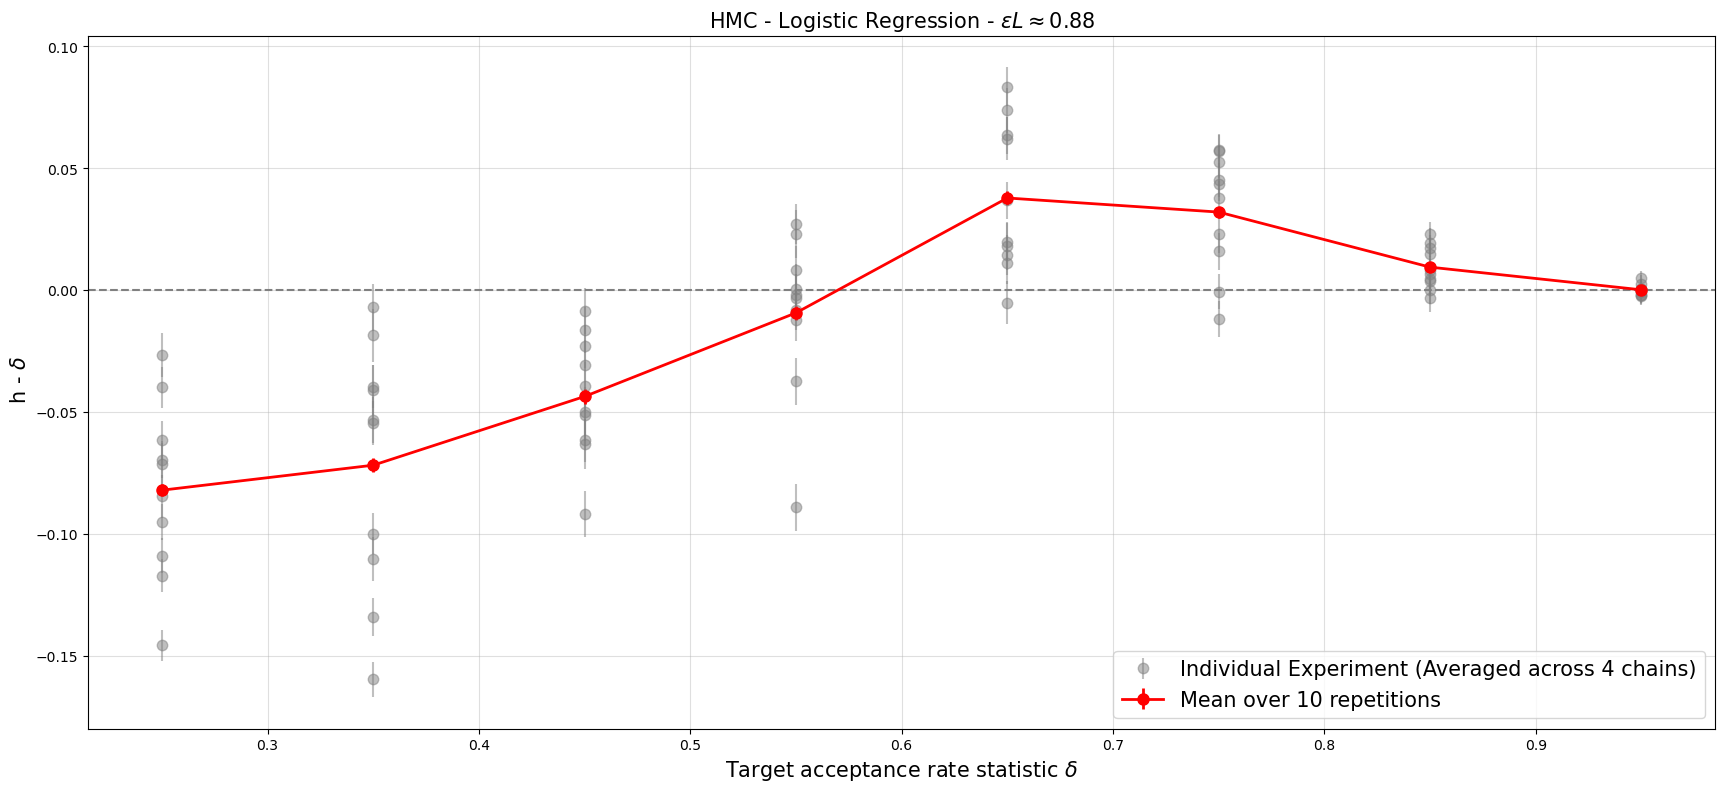

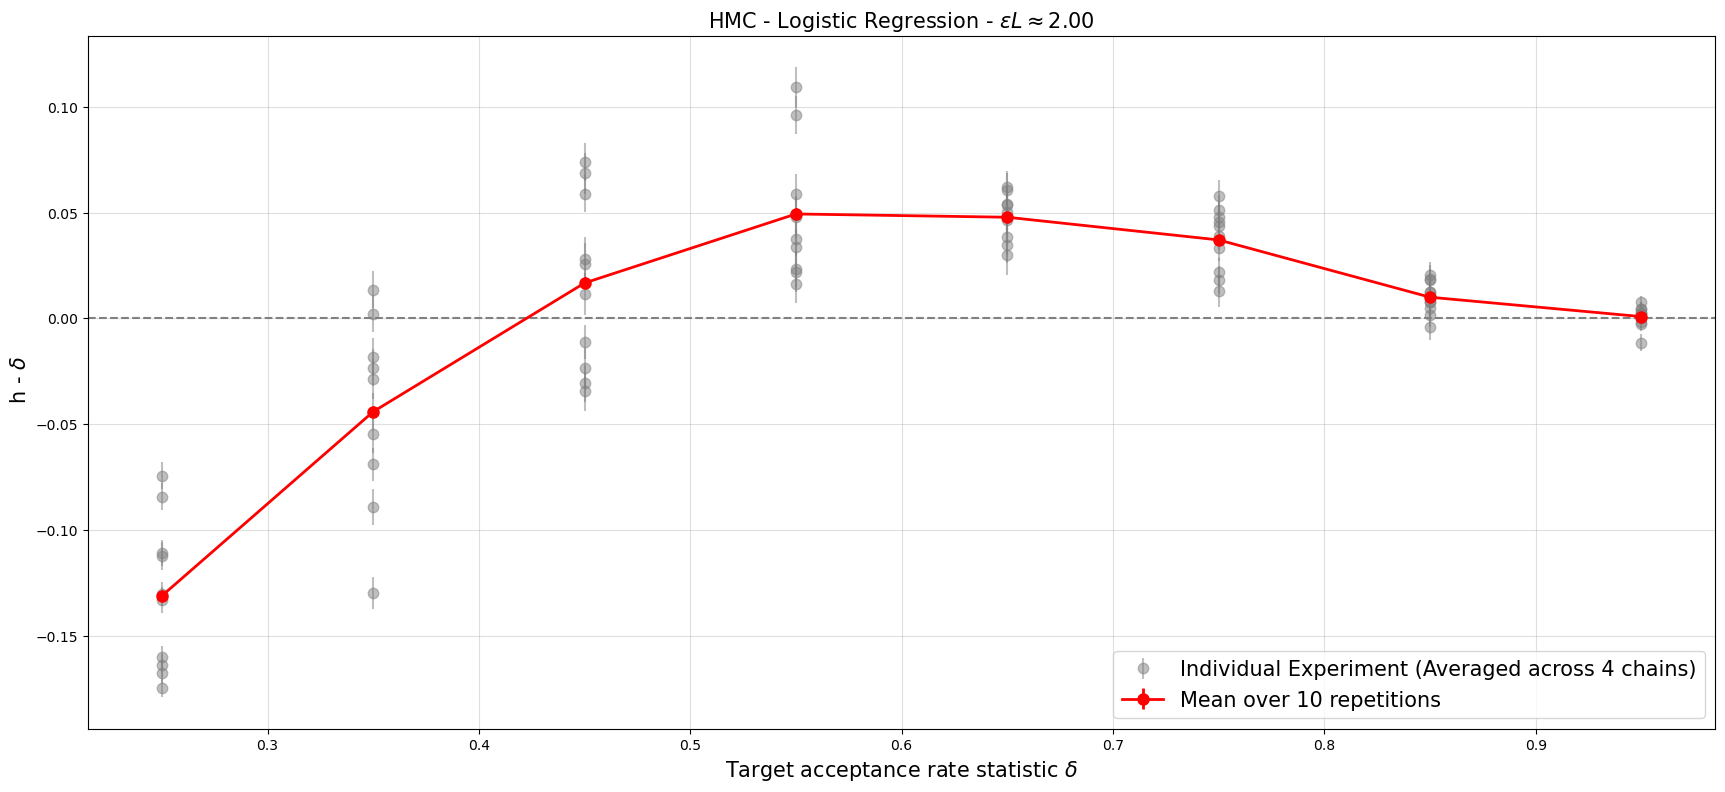

In [43]:
for val in (path_L_for_h_delta):

    val_df = df_HMC[ df_HMC["Path Length"] ==  val ]

    x_in_graph = val_df["Delta"].values
    
    # Plotting the single-experiment representation
    fig, ax = plt.subplots(figsize=(21,9))
    
    # Plot with errorbars using the combined metrics
    ax.errorbar(
        x = x_in_graph, 
        y = val_df["Diff"], 
        yerr = val_df["MCSE"], 
        ls="None", 
        marker=".", 
        ms=15, 
        label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
        color="gray",
        alpha = 0.5
    )
    
    ax.errorbar(x = delta_list_HMC,
                y = val_df.groupby(by="Delta").mean()["Diff"],
                yerr = val_df.groupby(by="Delta")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / reps ),
                ls = "-",
                marker = "o",
                ms = 8,
                label = f"Mean over {reps} repetitions",
                color="red",
                lw = 2
    )
    
    plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
    plt.ylabel(r" h - $\delta$", fontsize=15)
    plt.title(rf"HMC - Logistic Regression - $\epsilon L \approx {val:.2f}$", fontsize=15)
    plt.legend(loc="lower right", fontsize=15)
    plt.axhline(y=0.0, ls="--", color="gray")
    plt.grid(alpha=0.4)
    plt.show()

## ESS / Grad

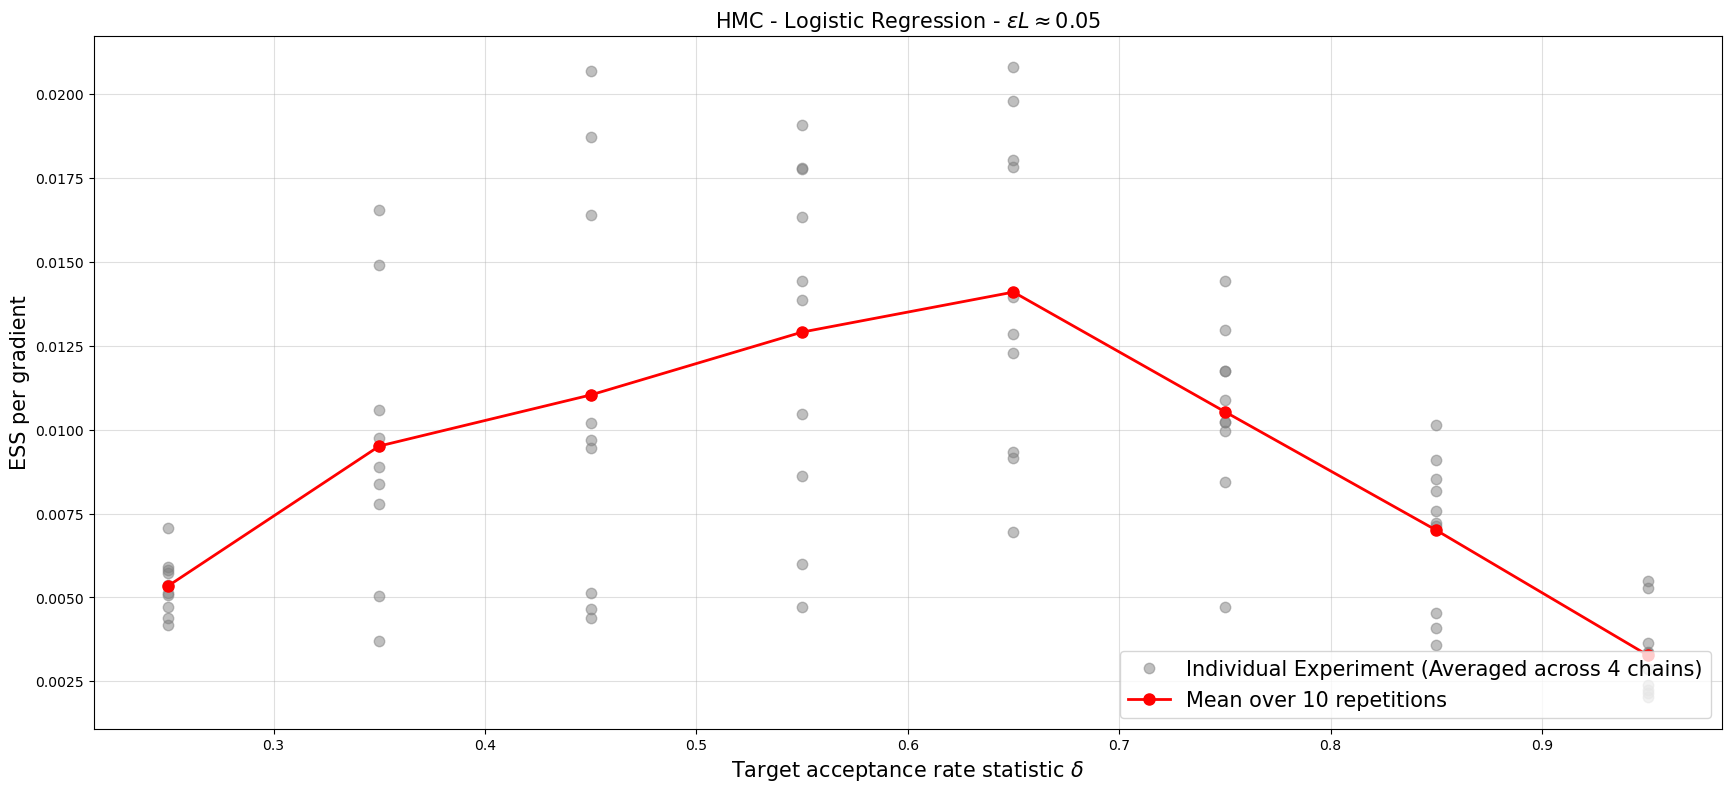

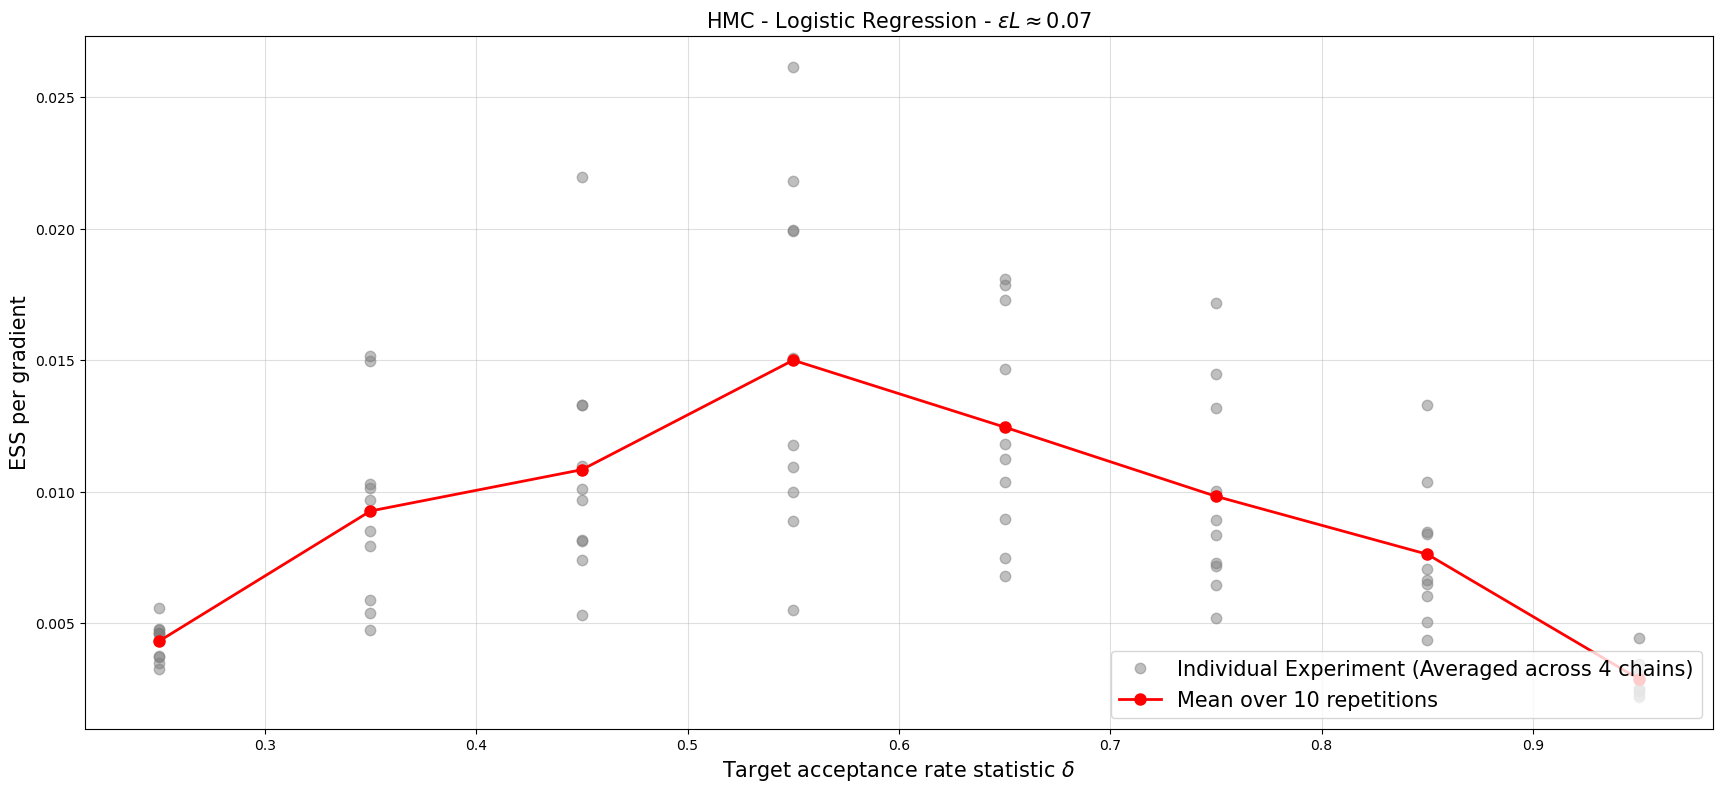

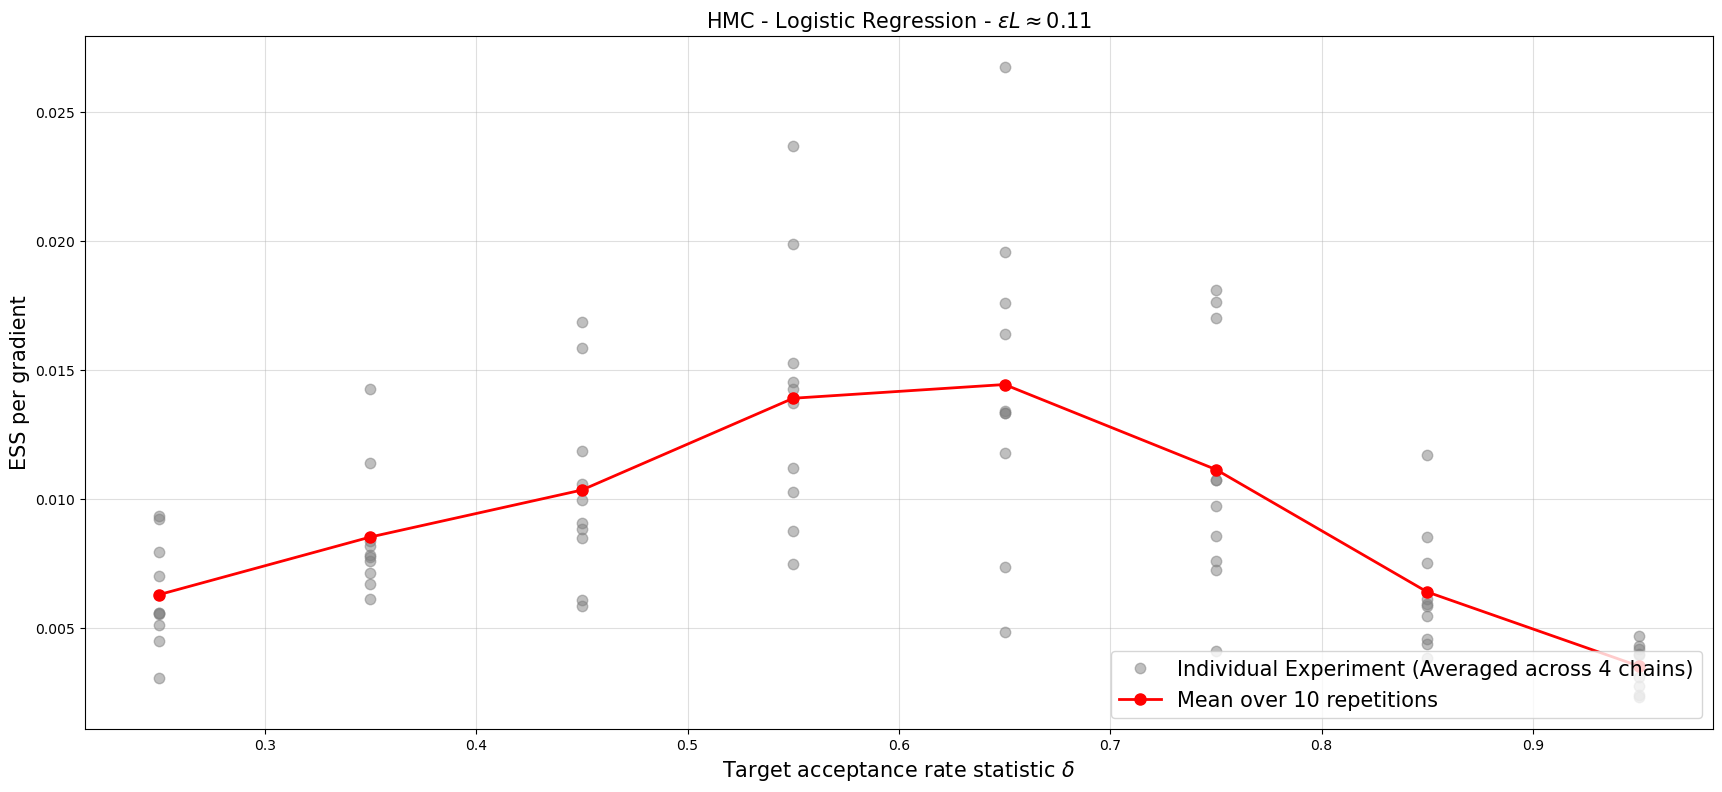

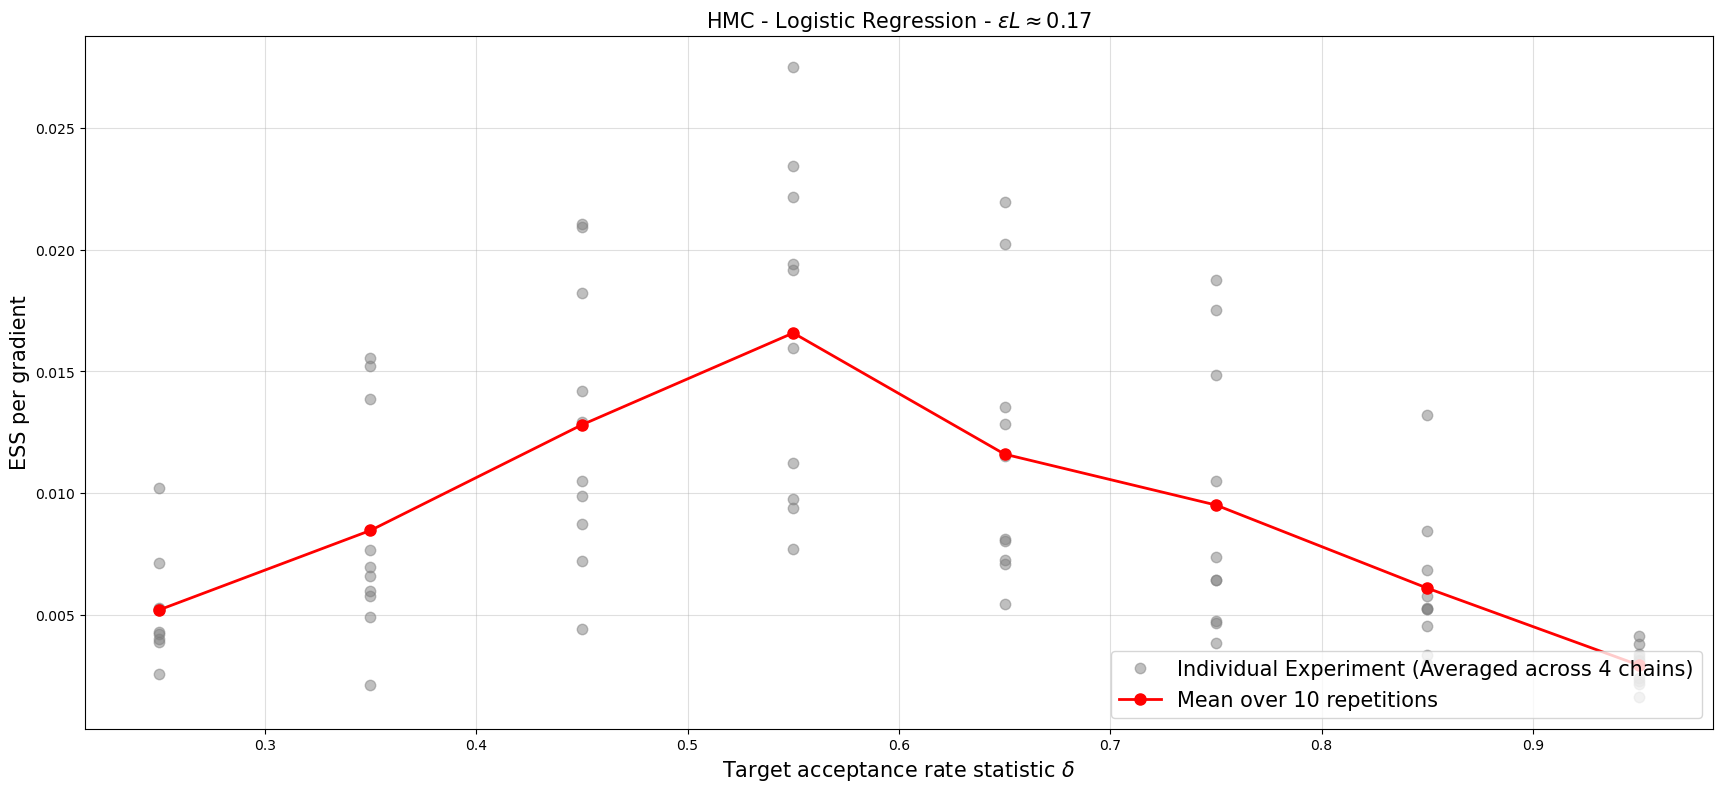

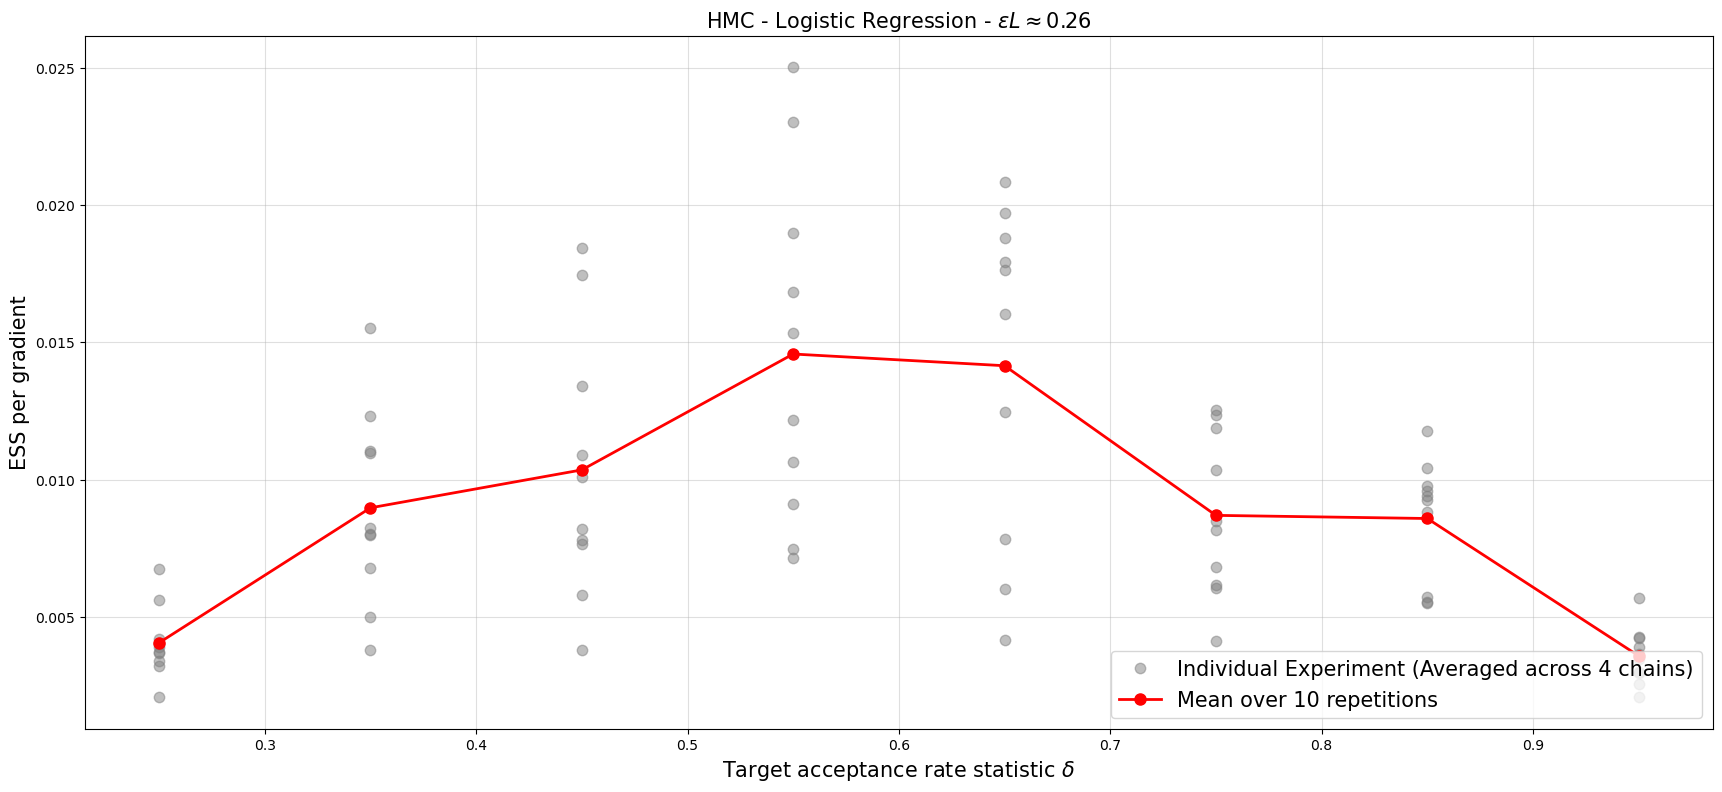

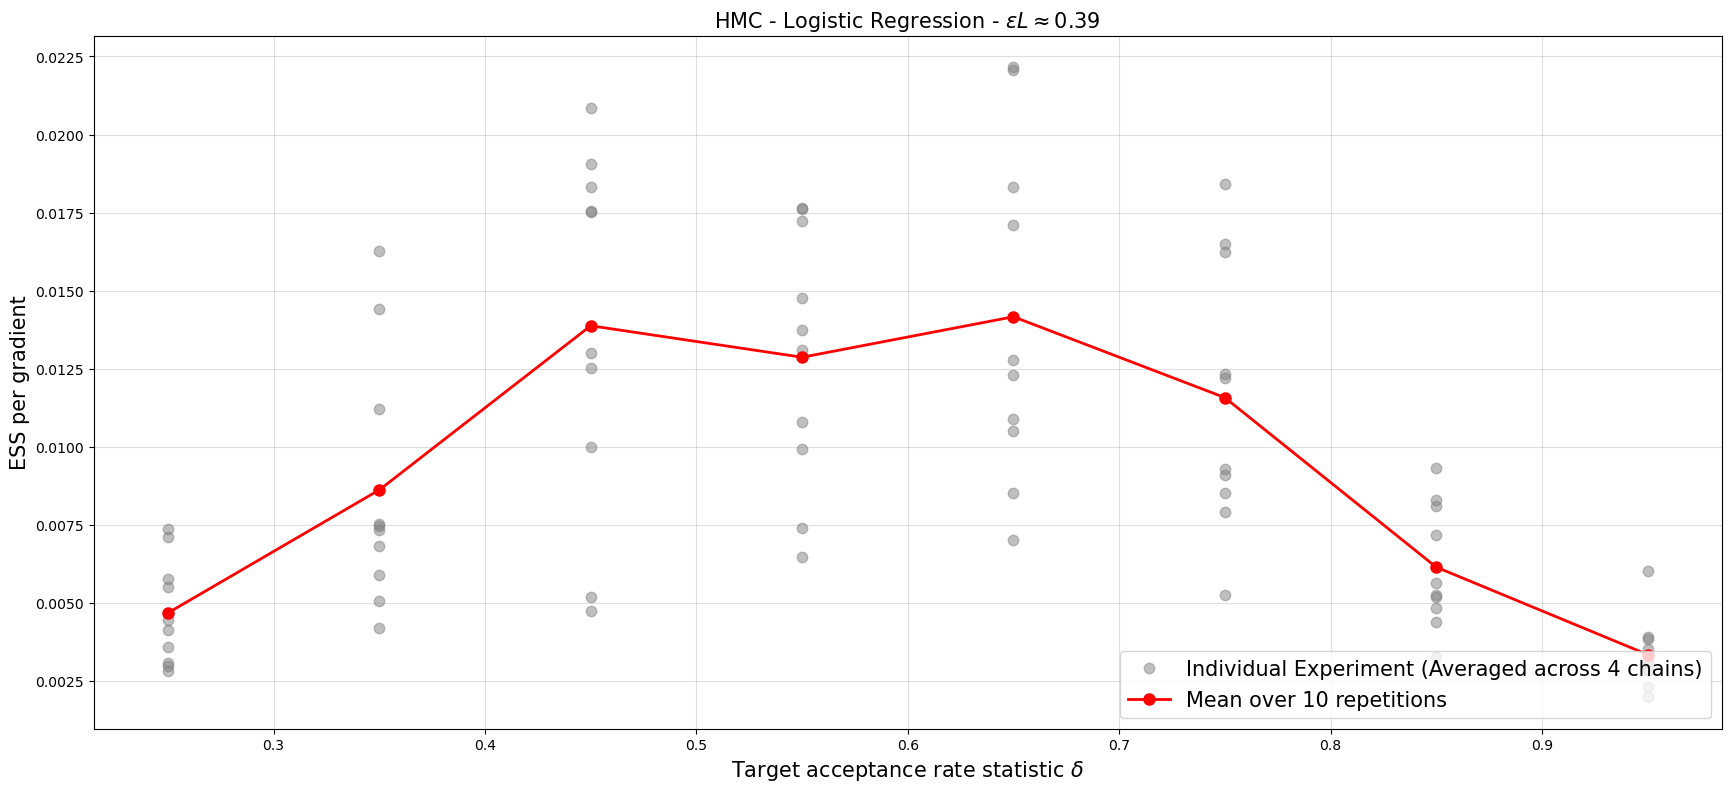

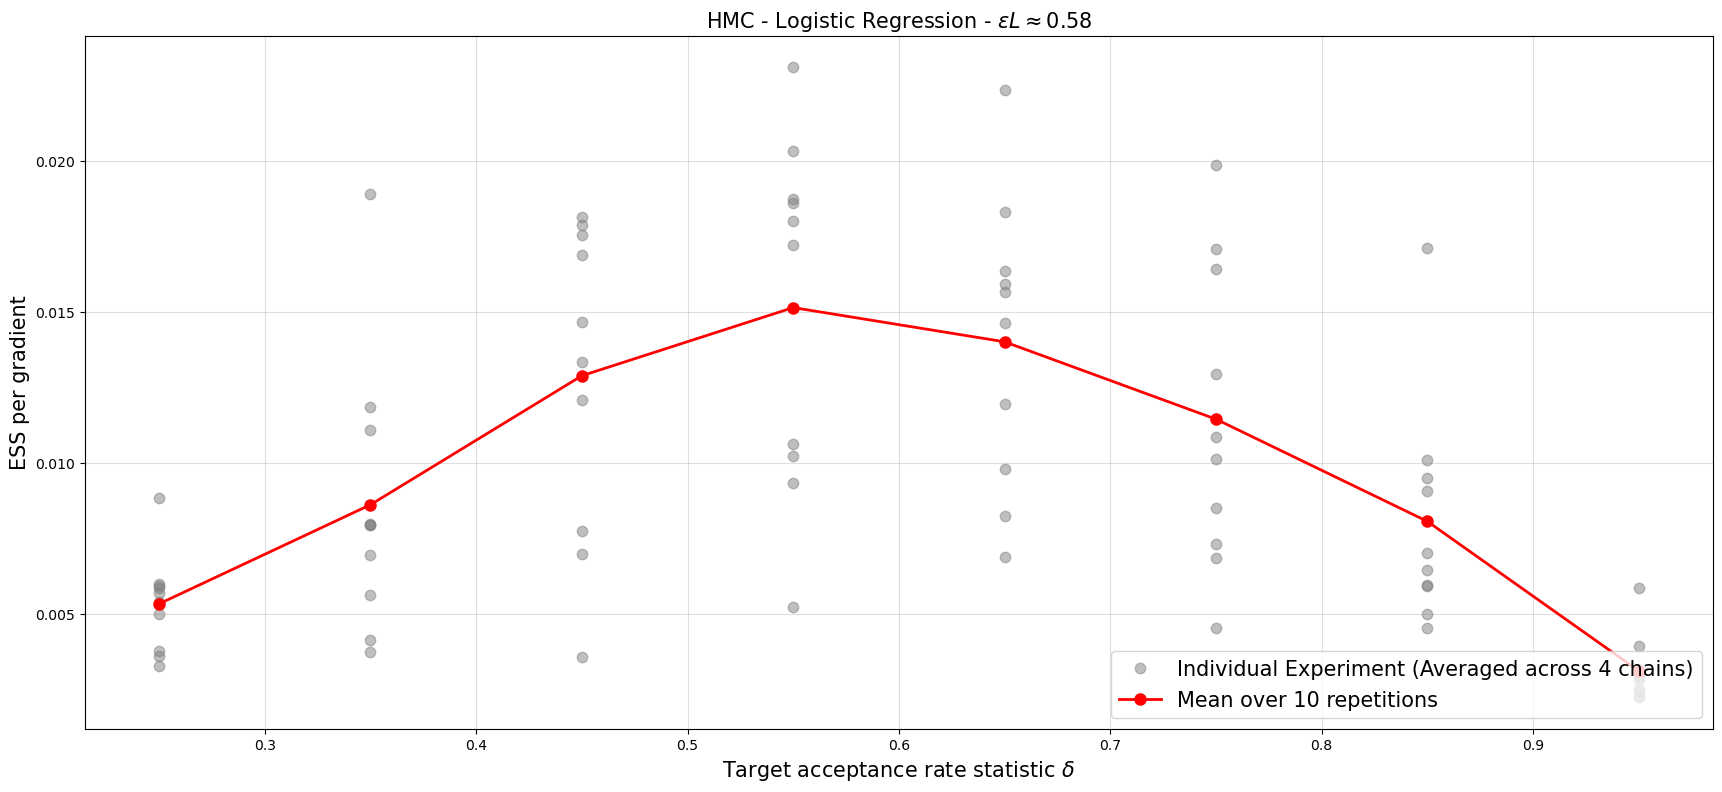

In [44]:
for val in (path_L_for_ESS):

    val_df = df_HMC[ df_HMC["Path Length"] ==  val ]

    x_in_graph = val_df["Delta"].values

    # Plotting the single-experiment representation
    fig, ax = plt.subplots(figsize=(21,9))
    
    # Plot with errorbars using the combined metrics
    ax.plot(
        x_in_graph, 
        val_df["Min"], 
        ls="None", 
        marker=".", 
        ms=15, 
        label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
        color="gray",
        alpha = 0.5
    )
    
    ax.plot(delta_list_HMC,
            val_df.groupby(by="Delta").mean()["Min"],
            ls = "-",
            marker = "o",
            ms = 8,
            label = f"Mean over {reps} repetitions",
            color="red",
            lw = 2
    )
    
    plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
    plt.ylabel("ESS per gradient", fontsize=15)
    plt.title(rf"HMC - Logistic Regression - $\epsilon L \approx {val:.2f}$", fontsize=15)
    plt.legend(loc="lower right", fontsize=15)
    plt.grid(alpha=0.4)
    plt.show()

In [45]:
df_HMC.to_pickle("HMC_HLR.pkl")